In [28]:
import os
import numpy as np
import pandas as pd
import librosa
import librosa.display
from sklearn.utils import resample
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score


In [29]:
import os
# Define paths
DATASET_PATH = "D:/LA/LA"
PROTOCOLS_PATH = os.path.join(DATASET_PATH, "ASVspoof2019_LA_cm_protocols")

# Define protocol files
protocol_files = {
    "train": os.path.join(PROTOCOLS_PATH, "ASVspoof2019.LA.cm.train.trn.txt"),
    "dev": os.path.join(PROTOCOLS_PATH, "ASVspoof2019.LA.cm.dev.trl.txt"),
    "eval": os.path.join(PROTOCOLS_PATH, "ASVspoof2019.LA.cm.eval.trl.txt"),
}

# Define audio directories
audio_dirs = {
    "train": os.path.join(DATASET_PATH, "ASVspoof2019_LA_train/flac"),
    "dev": os.path.join(DATASET_PATH, "ASVspoof2019_LA_dev/flac"),
    "eval": os.path.join(DATASET_PATH, "ASVspoof2019_LA_eval/flac"),
}

In [30]:
def load_protocol_data(protocol_path):
    # Load protocol file into DataFrame
    df = pd.read_csv(protocol_path, sep=" ", header=None, 
                    names=["Speaker_ID", "File_ID", "-", "Spoof_Type", "Label"])
    df = df[["File_ID", "Label"]]
    df["Label"] = df["Label"].map({"bonafide": 1, "spoof": 0})  # Convert labels to binary
    return df

In [31]:
df_train = load_protocol_data(protocol_files["train"])
df_dev = load_protocol_data(protocol_files["dev"])
df_eval = load_protocol_data(protocol_files["eval"])

print(df_train["Label"].value_counts())  # Kiểm tra phân phối dữ liệu
print(df_dev["Label"].value_counts())
print(df_eval["Label"].value_counts())

Label
0    22800
1     2580
Name: count, dtype: int64
Label
0    22296
1     2548
Name: count, dtype: int64
Label
0    63882
1     7355
Name: count, dtype: int64


**TRÍCH ĐẶC TRƯNG MFCC**

In [ ]:
import os
import numpy as np
import pandas as pd
import librosa
import joblib

# (Phần khai báo path và load protocol giữ nguyên từ code của bạn)

# Hàm trích xuất đặc trưng MFCC
def extract_features(file_path, n_mfcc=13, max_length=400):
    try:
        audio, sr = librosa.load(file_path, sr=16000)
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        if mfcc.shape[1] < max_length:
            pad_width = max_length - mfcc.shape[1]
            mfcc = np.pad(mfcc, pad_width=((0, 0), (0, pad_width)), mode='constant')
        else:
            mfcc = mfcc[:, :max_length]
        # Trả về full MFCC (không lấy mean ngay, để linh hoạt cho học sâu)
        return mfcc
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

# Hàm xử lý và lưu đặc trưng
def extract_and_save_features(df, audio_dir, output_file):
    X = []
    y = []
    for index, row in df.iterrows():
        file_id = row["File_ID"]
        label = row["Label"]
        file_path = os.path.join(audio_dir, f"{file_id}.flac")
        if os.path.exists(file_path):
            features = extract_features(file_path)
            if features is not None:
                X.append(features)
                y.append(label)
        else:
            print(f"File not found: {file_path}")
    X = np.array(X)  # Shape: (n_samples, n_mfcc, max_length)
    y = np.array(y)  # Shape: (n_samples,)
    # Lưu vào file
    np.savez(output_file, X=X, y=y)
    print(f"Saved features to {output_file}")

# Trích xuất và lưu cho từng tập
print("Processing training set...")
extract_and_save_features(df_train, audio_dirs["train"], "train_features.npz")
print("Processing development set...")
extract_and_save_features(df_dev, audio_dirs["dev"], "dev_features.npz")
print("Processing evaluation set...")
extract_and_save_features(df_eval, audio_dirs["eval"], "eval_features.npz")

Processing training set...
Saved features to train_features.npz
Processing development set...
Saved features to dev_features.npz
Processing evaluation set...
Saved features to eval_features.npz


1. ***MÔ HÌNH SVM***

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

# Hàm tải đặc trưng từ file .npz
def load_features(feature_file):
    data = np.load(feature_file)
    return data['X'], data['y']

# Tải dữ liệu đã trích xuất
print("Loading features...")
X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# Giảm chiều dữ liệu cho SVM (lấy trung bình theo trục thời gian)
X_train_flat = np.mean(X_train, axis=2)  # Shape: (n_samples, n_mfcc)
X_dev_flat = np.mean(X_dev, axis=2)      # Shape: (n_samples, n_mfcc)

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_dev_scaled = scaler.transform(X_dev_flat)

# Huấn luyện mô hình SVM
print("Training SVM model...")
svm_model = SVC(kernel='rbf', probability=True, random_state=42)  # probability=True để tính AUC
svm_model.fit(X_train_scaled, y_train)

# Dự đoán trên tập dev
y_pred = svm_model.predict(X_dev_scaled)  # Nhãn dự đoán
y_prob = svm_model.predict_proba(X_dev_scaled)[:, 1]  # Xác suất lớp 1 (bonafide)

# Tính các chỉ số đánh giá
acc = accuracy_score(y_dev, y_pred)
auc = roc_auc_score(y_dev, y_prob)
f1 = f1_score(y_dev, y_pred)
conf_matrix = confusion_matrix(y_dev, y_pred)

# Tính EER (Equal Error Rate)
fpr, tpr, thresholds = roc_curve(y_dev, y_prob)
fnr = 1 - tpr
eer_threshold = thresholds[np.argmin(np.abs(fpr - fnr))]
eer = fpr[np.argmin(np.abs(fpr - fnr))]

# In kết quả
print("\nEvaluation Results on Development Set:")
print(f"Accuracy (ACC): {acc:.4f}")
print(f"AUC: {auc:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nEqual Error Rate (EER): {eer:.4f}")

import joblib

# Lưu mô hình SVM và scaler
joblib.dump(svm_model, "svm_model.joblib")
joblib.dump(scaler, "scaler.joblib")

Loading features...
Training SVM model...

Evaluation Results on Development Set:
Accuracy (ACC): 0.9116
AUC: 0.8382
F1-Score: 0.2846

Confusion Matrix:
[[22210    86]
 [ 2111   437]]

Equal Error Rate (EER): 0.2305


['scaler.joblib']

2. ***MÔ HÌNH GAUSSIAN NAIVE BAYES***

AUC: 0.6958

=== Development Set Evaluation ===
Accuracy: 0.5910
F1-score (weighted): 0.6707

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.58      0.72     22296
           1       0.15      0.67      0.25      2548

    accuracy                           0.59     24844
   macro avg       0.55      0.62      0.48     24844
weighted avg       0.86      0.59      0.67     24844


Confusion Matrix:
[[12984  9312]
 [  849  1699]]


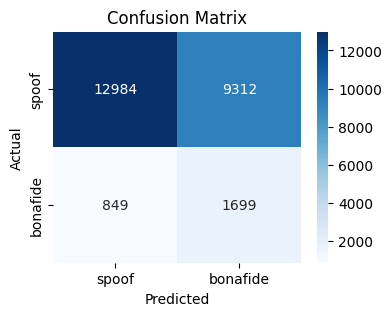

Model saved as 'gaussian_mfcc_model.pkl'


In [2]:
import numpy as np
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                            confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import joblib
# 1. Load dữ liệu
def load_features(file_path):
    data = np.load(file_path)
    return data['X'], data['y']

X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# 2. Chuẩn bị dữ liệu (lấy mean theo time axis)
X_train_2d = np.mean(X_train, axis=2)
X_dev_2d = np.mean(X_dev, axis=2)

# 3. Chuyển đổi nhãn sang dạng số nếu chưa phải
le = LabelEncoder()
y_train = le.fit_transform(y_train)
y_dev = le.transform(y_dev)

# 4. Huấn luyện mô hình
gnb = GaussianNB(var_smoothing=1e-9)
gnb.fit(X_train_2d, y_train)

# 5. Dự đoán trên tập development
y_dev_pred = gnb.predict(X_dev_2d)
y_dev_proba = gnb.predict_proba(X_dev_2d)

# 6. Tính các chỉ số đánh giá
# Accuracy
acc = accuracy_score(y_dev, y_dev_pred)

# AUC (chỉ tính cho binary classification hoặc từng lớp riêng lẻ)
if len(gnb.classes_) == 2:
    auc = roc_auc_score(y_dev, y_dev_proba[:, 1])
    print(f"AUC: {auc:.4f}")
else:
    print("AUC for each class (one-vs-rest):")
    for i, class_name in enumerate(le.classes_):
        auc = roc_auc_score((y_dev == i).astype(int), y_dev_proba[:, i])
        print(f"{class_name}: {auc:.4f}")

# F1-score
f1 = f1_score(y_dev, y_dev_pred, average='weighted')

# Confusion matrix
cm = confusion_matrix(y_dev, y_dev_pred)

# 7. In kết quả
print("\n=== Development Set Evaluation ===")
print(f"Accuracy: {acc:.4f}")
print(f"F1-score (weighted): {f1:.4f}\n")

print("Classification Report:")
# Chuyển đổi classes_ sang chuỗi nếu cần
target_names = [str(cls) for cls in le.classes_]
print(classification_report(y_dev, y_dev_pred, target_names=target_names))

print("\nConfusion Matrix:")
print(cm)

# 8. Visualize confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
           xticklabels=["spoof", "bonafide"], yticklabels=["spoof", "bonafide"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

joblib.dump(gnb, "gaussian_mfcc_model.pkl")
print("Model saved as 'gaussian_mfcc_model.pkl'")

***3.MÔ HÌNH BERNOURLLI NAIVE BAYES***

Accuracy: 0.8979
F1-score (weighted): 0.8503

AUC (Development): 0.6958
Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     22296
           1       0.88      0.01      0.01      2548

    accuracy                           0.90     24844
   macro avg       0.89      0.50      0.48     24844
weighted avg       0.90      0.90      0.85     24844


Confusion Matrix:
[[22294     2]
 [ 2534    14]]


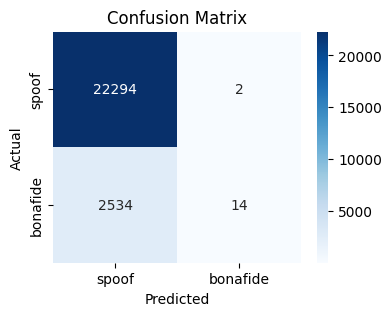

Model saved as 'bernoulli_nb_mfcc_model.pkl'


In [ ]:
import numpy as np
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import Binarizer
import joblib
# Load dữ liệu đặc trưng
def load_features(file_path):
    data = np.load(file_path)
    return data['X'], data['y']

X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# Chuẩn bị dữ liệu (lấy mean theo time axis)
X_train_2d = np.mean(X_train, axis=2)
X_dev_2d = np.mean(X_dev, axis=2)

# Chuyển đổi đặc trưng MFCC sang dạng nhị phân
binarizer = Binarizer(threshold=0)  # Giá trị > 0 thành 1, ngược lại 0
X_train_bin = binarizer.fit_transform(X_train_2d)
X_dev_bin = binarizer.transform(X_dev_2d)

# Khởi tạo và huấn luyện mô hình
bnb = BernoulliNB(alpha=1.0, binarize=None)  # Đã binarize trước đó nên set binarize=None
bnb.fit(X_train_bin, y_train)

# Dự đoán trên tập development
y_dev_pred = bnb.predict(X_dev_bin)

# Đánh giá mô hình
print(f"Accuracy: {accuracy_score(y_dev, y_dev_pred):.4f}")
print(f"F1-score (weighted): {f1_score(y_dev, y_dev_pred, average='weighted'):.4f}\n")
auc = roc_auc_score(y_dev, y_dev_proba[:, 1])
print(f"AUC (Development): {auc:.4f}")
print("Classification Report:")
print(classification_report(y_dev, y_dev_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_dev, y_dev_pred))

plt.figure(figsize=(4,3))
sns.heatmap(confusion_matrix(y_dev, y_dev_pred), annot=True, fmt='d', cmap='Blues',
           xticklabels=["spoof", "bonafide"], yticklabels=["spoof", "bonafide"])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

joblib.dump(bnb, "bernoulli_nb_mfcc_model.pkl")
print("Model saved as 'bernoulli_nb_mfcc_model.pkl'")

4. ***MÔ HÌNH RANDOM FOREST***

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, roc_curve
import matplotlib.pyplot as plt

# Hàm tải đặc trưng từ file .npz
def load_features(feature_file):
    data = np.load(feature_file)
    return data['X'], data['y']

# Tải dữ liệu đã trích xuất
print("Loading features...")
X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# Giảm chiều dữ liệu cho Random Forest (lấy trung bình theo trục thời gian)
X_train_flat = np.mean(X_train, axis=2)  # Shape: (n_samples, n_mfcc)
X_dev_flat = np.mean(X_dev, axis=2)      # Shape: (n_samples, n_mfcc)

# Chuẩn hóa dữ liệu (không bắt buộc với RF, nhưng có thể cải thiện hiệu suất)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_flat)
X_dev_scaled = scaler.transform(X_dev_flat)

# Huấn luyện mô hình Random Forest
print("Training Random Forest model...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)  # n_estimators=100 cây, n_jobs=-1 dùng tất cả CPU
rf_model.fit(X_train_scaled, y_train)

# Dự đoán trên tập dev
y_pred = rf_model.predict(X_dev_scaled)  # Nhãn dự đoán
y_prob = rf_model.predict_proba(X_dev_scaled)[:, 1]  # Xác suất lớp 1 (bonafide)

# Tính các chỉ số đánh giá
acc = accuracy_score(y_dev, y_pred)
auc = roc_auc_score(y_dev, y_prob)
f1 = f1_score(y_dev, y_pred)
conf_matrix = confusion_matrix(y_dev, y_pred)

# Tính EER (Equal Error Rate)
fpr, tpr, thresholds = roc_curve(y_dev, y_prob)
fnr = 1 - tpr
eer_threshold = thresholds[np.argmin(np.abs(fpr - fnr))]
eer = fpr[np.argmin(np.abs(fpr - fnr))]

# In kết quả
print("\nEvaluation Results on Development Set:")
print(f"Accuracy (ACC): {acc:.4f}")
print(f"AUC: {auc:.4f}")
print(f"F1-Score: {f1:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print(f"\nEqual Error Rate (EER): {eer:.4f}")

Loading features...
Training Random Forest model...

Evaluation Results on Development Set:
Accuracy (ACC): 0.9083
AUC: 0.8612
F1-Score: 0.2086

Confusion Matrix:
[[22267    29]
 [ 2248   300]]

Equal Error Rate (EER): 0.2278


5. ***MÔ HÌNH KNN***

Loading training features...
Loading development features...
Training KNN model...
Evaluating on development set...

--- Development Set Evaluation ---
Accuracy: 0.9122
AUC: 0.7262
F1-Score: 0.2879
Classification Report:
               precision    recall  f1-score   support

       spoof       0.91      1.00      0.95     22296
    bonafide       0.85      0.17      0.29      2548

    accuracy                           0.91     24844
   macro avg       0.88      0.58      0.62     24844
weighted avg       0.91      0.91      0.88     24844



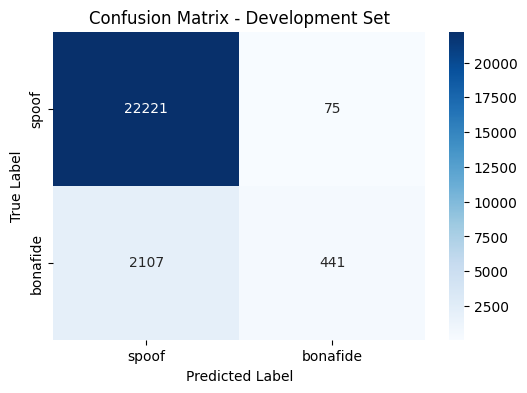

In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns

# Load protocol files into DataFrames (chỉ dùng để kiểm tra nếu cần)
def load_protocol(file_path):
    df = pd.read_csv(file_path, sep=" ", header=None, 
                     names=["Speaker_ID", "File_ID", "Unknown1", "Attack_ID", "Label"])
    df = df[["File_ID", "Label"]]
    df["Label"] = df["Label"].apply(lambda x: 1 if x == "bonafide" else 0)
    return df

# Load pre-extracted features
print("Loading training features...")
train_data = np.load("train_features.npz")
X_train, y_train = train_data["X"], train_data["y"]

print("Loading development features...")
dev_data = np.load("dev_features.npz")
X_dev, y_dev = dev_data["X"], dev_data["y"]


# Flatten the MFCC features for KNN
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # Shape: (n_samples, n_mfcc * max_length)
X_dev_flat = X_dev.reshape(X_dev.shape[0], -1)

# Train KNN model
knn = KNeighborsClassifier(n_neighbors=5)  # Default k=5, có thể điều chỉnh
print("Training KNN model...")
knn.fit(X_train_flat, y_train)

# Function to evaluate and plot confusion matrix
def evaluate_model(y_true, y_pred, y_prob, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n--- {dataset_name} Set Evaluation ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=["spoof", "bonafide"]))
    
    # Plot Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["spoof", "bonafide"], yticklabels=["spoof", "bonafide"])
    plt.title(f"Confusion Matrix - {dataset_name} Set")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

# Predict and evaluate on development set
print("Evaluating on development set...")
y_dev_pred = knn.predict(X_dev_flat)
y_dev_prob = knn.predict_proba(X_dev_flat)[:, 1]  # Probability for positive class (bonafide)
evaluate_model(y_dev, y_dev_pred, y_dev_prob, "Development")


6. ***MÔ HÌNH CNN***

Loading training features...
Loading development features...


c:\Users\VanKhanh\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 398, 32)        │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 398, 32)        │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 199, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 199, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 197, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 197, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 98, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 98, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 96, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 96, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 48, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6144)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       393,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 426,433 (1.63 MB)

 Trainable params: 425,985 (1.63 MB)

 Non-trainable params: 448 (1.75 KB)

Training CNN model...
Epoch 1/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 17s 18ms/step - accuracy: 0.9009 - loss: 1.7061 - val_accuracy: 0.9297 - val_loss: 0.4642
Epoch 2/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9629 - loss: 0.3626 - val_accuracy: 0.9449 - val_loss: 0.2949
Epoch 3/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 13s 17ms/step - accuracy: 0.9667 - loss: 0.2750 - val_accuracy: 0.9300 - val_loss: 0.3373
Epoch 4/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9768 - loss: 0.2191 - val_accuracy: 0.9402 - val_loss: 0.2858
Epoch 5/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9778 - loss: 0.2064 - val_accuracy: 0.8689 - val_loss: 0.5154
Epoch 6/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9740 - loss: 0.2233 - val_accuracy: 0.9481 - val_loss: 0.2736
Epoch 7/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accuracy: 0.9770 - loss: 0.2251 - val_accuracy: 0.9591 - val_loss: 0.2536
Epoch 8/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 14s 17ms/step - accu

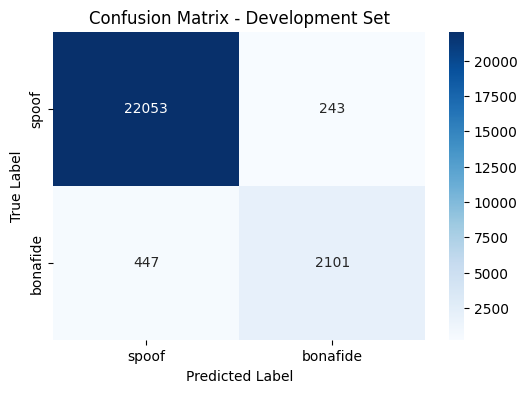

Model saved to audio_spoofing_cnn_model.h5


In [ ]:
import os
import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                             confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

# Load pre-extracted features
print("Loading training features...")
train_data = np.load("train_features.npz")
X_train, y_train = train_data["X"], train_data["y"]

print("Loading development features...")
dev_data = np.load("dev_features.npz")
X_dev, y_dev = dev_data["X"], dev_data["y"]

# Reshape data for Conv1D: (n_samples, max_length, n_mfcc)
X_train = np.transpose(X_train, (0, 2, 1))  # Shape: (n_samples, 400, 13)
X_dev = np.transpose(X_dev, (0, 2, 1))

# Define CNN model with regularization
def create_cnn_model(input_shape):
    model = Sequential([
        Conv1D(32, kernel_size=3, activation='relu', input_shape=input_shape, kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        Conv1D(64, kernel_size=3, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        Conv1D(128, kernel_size=3, activation='relu', kernel_regularizer=l2(0.01)),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        Flatten(),
        Dense(64, activation='relu', kernel_regularizer=l2(0.01)),
        Dropout(0.5),
        Dense(1, activation='sigmoid')  # Binary classification
    ])
    model.compile(optimizer='adam', 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    return model

# Create model
input_shape = (X_train.shape[1], X_train.shape[2])  # (max_length, n_mfcc) = (400, 13)
model = create_cnn_model(input_shape)
model.summary()

# Define training parameters
batch_size = 32
epochs = 100

# Early stopping to prevent overfitting
early_stopping = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

# Train the model
print("Training CNN model...")
history = model.fit(X_train, y_train, 
                    batch_size=batch_size, 
                    epochs=epochs, 
                    validation_data=(X_dev, y_dev),  # Tập dev được dùng làm validation
                    callbacks=[early_stopping])

# Function to evaluate and plot confusion matrix
def evaluate_model(y_true, y_pred, y_prob, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n--- {dataset_name} Set Evaluation ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=["spoof", "bonafide"]))
    
    # Plot Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["spoof", "bonafide"], yticklabels=["spoof", "bonafide"])
    plt.title(f"Confusion Matrix - {dataset_name} Set")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.show()

# Predict and evaluate on development set
print("Evaluating on development set...")
y_dev_prob = model.predict(X_dev, batch_size=batch_size).flatten()  # Dự đoán xác suất trên dev
y_dev_pred = (y_dev_prob > 0.5).astype(int)  # Chuyển thành nhãn nhị phân
evaluate_model(y_dev, y_dev_pred, y_dev_prob, "Development")  # Đánh giá trên dev

# Save the model with .h5 extension
model_save_path = "audio_spoofing_cnn_model.h5"
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

7. ***MÔ HÌNH LSTM***

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, TimeDistributed, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Load features
def load_features(file):
    data = np.load(file)
    return data['X'], data['y']

X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# Reshape để phù hợp với đầu vào của LSTM
X_train = np.transpose(X_train, (0, 2, 1))  # (samples, timesteps, features)
X_dev = np.transpose(X_dev, (0, 2, 1))

# One-hot encoding nhãn
y_train = to_categorical(y_train)
y_dev = to_categorical(y_dev)

# Xây dựng mô hình LSTM
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    LSTM(64, return_sequences=True),
    Dropout(0.3),
    LSTM(32),
    Dropout(0.3),
    Dense(y_train.shape[1], activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Huấn luyện mô hình
model.fit(X_train, y_train, validation_data=(X_dev, y_dev), epochs=100, batch_size=32)

# Đánh giá trên tập kiểm tra
dev_loss, dev_acc = model.evaluate(X_dev, y_dev)
print(f"Evaluation Accuracy: {dev_acc:.4f}")

# Lưu mô hình
model.save("lstm_speech_model.h5")

C:\Users\VanKhanh\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 232s 288ms/step - accuracy: 0.9001 - loss: 0.3497 - val_accuracy: 0.8974 - val_loss: 0.3314
Epoch 2/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 227s 286ms/step - accuracy: 0.9023 - loss: 0.3244 - val_accuracy: 0.8974 - val_loss: 0.3330
Epoch 3/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 231s 291ms/step - accuracy: 0.8998 - loss: 0.3275 - val_accuracy: 0.8974 - val_loss: 0.3307
Epoch 4/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 228s 288ms/step - accuracy: 0.8993 - loss: 0.3308 - val_accuracy: 0.8974 - val_loss: 0.3307
Epoch 5/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 227s 286ms/step - accuracy: 0.8993 - loss: 0.3300 - val_accuracy: 0.8974 - val_loss: 0.3309
Epoch 6/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 230s 289ms/step - accuracy: 0.8984 - loss: 0.3325 - val_accuracy: 0.8974 - val_loss: 0.3310
Epoch 7/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 228s 288ms/step - accuracy: 0.9015 - loss: 0.3240 - val_accuracy: 0.8974 - val_loss: 0.3307
Epoch 8/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 266s 336ms/step - accuracy: 

777/777 ━━━━━━━━━━━━━━━━━━━━ 52s 66ms/step
Evaluation Accuracy: 0.9750
AUC Score: 0.9900
F1 Score: 0.9738
Error Rate: 0.0250
Confusion Matrix:
[[22228    68]
 [  553  1995]]


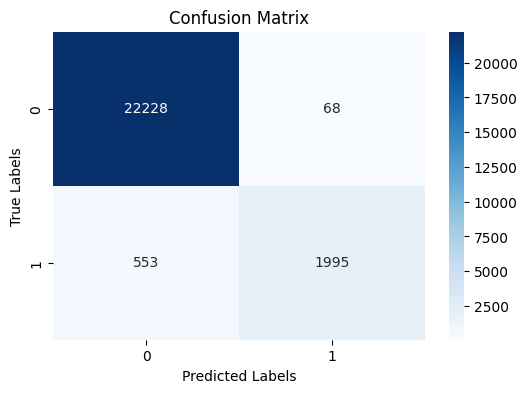

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix

# Load features
def load_features(file):
    data = np.load(file)
    return data['X'], data['y']

X_dev, y_dev = load_features("dev_features.npz")
X_dev = np.transpose(X_dev, (0, 2, 1))  # (samples, timesteps, features)
y_dev = to_categorical(y_dev)

# Load mô hình đã lưu
model = load_model("lstm_speech_model.h5")

# Đánh giá trên tập kiểm tra
y_pred = model.predict(X_dev)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_dev, axis=1)

acc = accuracy_score(y_true, y_pred_classes)
auc = roc_auc_score(y_dev, y_pred, multi_class='ovr')
f1 = f1_score(y_true, y_pred_classes, average='weighted')
conf_matrix = confusion_matrix(y_true, y_pred_classes)
err = 1 - acc

print(f"Evaluation Accuracy: {acc:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Error Rate: {err:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

# Vẽ confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()


8. ***MÔ HÌNH VGG16***

Epoch 1/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 348s 432ms/step - accuracy: 0.8920 - loss: 0.3677 - val_accuracy: 0.8974 - val_loss: 0.4688
Epoch 2/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 621s 782ms/step - accuracy: 0.8953 - loss: 0.3476 - val_accuracy: 0.8974 - val_loss: 0.3310
Epoch 3/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 576s 723ms/step - accuracy: 0.8996 - loss: 0.3244 - val_accuracy: 0.8974 - val_loss: 0.3309
Epoch 4/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 349s 440ms/step - accuracy: 0.9010 - loss: 0.2634 - val_accuracy: 0.8976 - val_loss: 0.3463
Epoch 5/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 344s 434ms/step - accuracy: 0.8963 - loss: 0.3046 - val_accuracy: 0.8974 - val_loss: 0.3296
Epoch 6/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 347s 437ms/step - accuracy: 0.9031 - loss: 0.2537 - val_accuracy: 0.8974 - val_loss: 0.3884
Epoch 7/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 353s 444ms/step - accuracy: 0.8982 - loss: 0.3520 - val_accuracy: 0.8974 - val_loss: 0.3310
Epoch 8/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 350s 440ms/step - accuracy: 

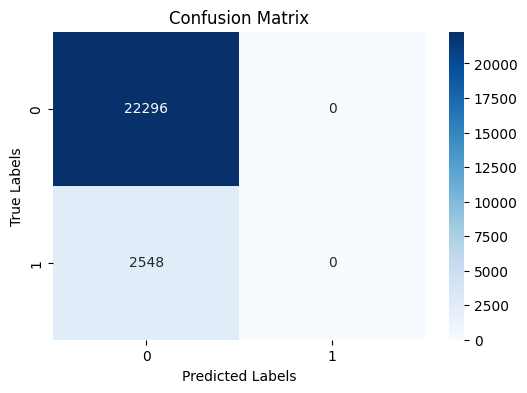

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix

# Load features
def load_features(file):
    data = np.load(file)
    return data['X'], data['y']

X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# Resize dữ liệu thành kích thước tối thiểu (32x32)
def resize_features(X):
    X_resized = np.array([tf.image.resize(img[..., np.newaxis], (32, 32)).numpy() for img in X])
    return X_resized

X_train = resize_features(X_train)
X_dev = resize_features(X_dev)

# One-hot encoding nhãn
y_train = to_categorical(y_train)
y_dev = to_categorical(y_dev)

# Xây dựng mô hình VGG16 tùy chỉnh
input_shape = X_train.shape[1:]  # (32, 32, 1)
base_model = VGG16(include_top=False, weights=None, input_shape=input_shape)

model = Sequential([
    base_model,
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(y_train.shape[1], activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Huấn luyện mô hình
model.fit(X_train, y_train, validation_data=(X_dev, y_dev), epochs=100, batch_size=32)

# Đánh giá trên tập kiểm tra
y_pred = model.predict(X_dev)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_dev, axis=1)

acc = accuracy_score(y_true, y_pred_classes)
auc = roc_auc_score(y_dev, y_pred, multi_class='ovr')
f1 = f1_score(y_true, y_pred_classes, average='weighted')
conf_matrix = confusion_matrix(y_true, y_pred_classes)
err = 1 - acc

print(f"Evaluation Accuracy: {acc:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Error Rate: {err:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

# Vẽ confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Lưu mô hình
model.save("vgg16_speech_model.h5")


9. ***MÔ HÌNH VGG19***

Epoch 1/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 742ms/step - accuracy: 0.8936 - auc: 0.8972 - loss: 0.3809 - precision: 0.8936 - recall: 0.8936

794/794 ━━━━━━━━━━━━━━━━━━━━ 738s 924ms/step - accuracy: 0.8936 - auc: 0.8972 - loss: 0.3808 - precision: 0.8936 - recall: 0.8936 - val_accuracy: 0.8974 - val_auc: 0.8974 - val_loss: 0.3320 - val_precision: 0.8974 - val_recall: 0.8974
Epoch 2/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 732s 922ms/step - accuracy: 0.8980 - auc: 0.8990 - loss: 0.3332 - precision: 0.8980 - recall: 0.8980 - val_accuracy: 0.8974 - val_auc: 0.8974 - val_loss: 0.3307 - val_precision: 0.8974 - val_recall: 0.8974
Epoch 3/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 727s 915ms/step - accuracy: 0.8960 - auc: 0.8972 - loss: 0.3373 - precision: 0.8960 - recall: 0.8960 - val_accuracy: 0.8974 - val_auc: 0.8974 - val_loss: 0.3308 - val_precision: 0.8974 - val_recall: 0.8974
Epoch 4/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 729s 918ms/step - accuracy: 0.9013 - auc: 0.9043 - loss: 0.3237 - precision: 0.9013 - recall: 0.9013 - val_accuracy: 0.8974 - val_auc: 0.8974 - val_loss: 0.3315 - val_precision: 0.8974 - val_recall: 0.8974
Epoch 5/100
794/794 ━━━━

c:\Users\VanKhanh\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\VanKhanh\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\VanKhanh\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(avera

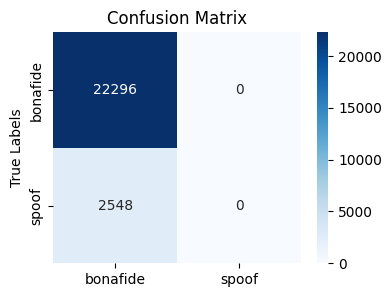


Model saved as asv_spoof_vgg19_model.h5


In [39]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report

# Load features
def load_features(file):
    data = np.load(file)
    return data['X'], data['y']

X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# Resize dữ liệu thành (48x48) để phù hợp với VGG
def resize_features(X):
    X_resized = np.array([tf.image.resize(img[..., np.newaxis], (48, 48)).numpy() for img in X])
    return X_resized

X_train = resize_features(X_train)
X_dev = resize_features(X_dev)

# One-hot encoding nhãn
y_train = to_categorical(y_train)
y_dev = to_categorical(y_dev)

# Xây dựng mô hình VGG19
def build_vgg19(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    
    # Block 1
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2))(x)
    
    # Block 2
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), strides=(2, 2))(x)
    
    # Block 3
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)  # Thêm lớp so với VGG18
    x = MaxPooling2D((2, 2), strides=(2, 2))(x)
    
    # Block 4
    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)  # Thêm lớp so với VGG18
    x = MaxPooling2D((2, 2), strides=(2, 2))(x)
    
    # Block 5
    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)
    x = Conv2D(512, (3, 3), activation='relu', padding='same')(x)  # Thêm lớp so với VGG18
    x = MaxPooling2D((2, 2), strides=(2, 2))(x)
    
    # Fully connected layers
    x = Flatten()(x)
    x = Dense(4096, activation='relu')(x)
    x = Dropout(0.5)(x)
    x = Dense(4096, activation='relu')(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs, name='VGG19')
    return model

# Xây dựng và biên dịch mô hình
input_shape = X_train.shape[1:]  # (48, 48, 1)
model = build_vgg19(input_shape, y_train.shape[1])

model.compile(optimizer=Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy', 
                      tf.keras.metrics.Precision(name='precision'),
                      tf.keras.metrics.Recall(name='recall'),
                      tf.keras.metrics.AUC(name='auc')])

# Callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ModelCheckpoint('best_vgg19_model.h5', monitor='val_auc', mode='max', save_best_only=True)
]

# Huấn luyện mô hình
history = model.fit(
    X_train, y_train,
    validation_data=(X_dev, y_dev),
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

# Đánh giá mô hình
model.load_weights('best_vgg19_model.h5')
y_pred = model.predict(X_dev)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_dev, axis=1)

# Tính các metrics
acc = accuracy_score(y_true, y_pred_classes)
auc = roc_auc_score(y_dev, y_pred, multi_class='ovr')
f1 = f1_score(y_true, y_pred_classes, average='weighted')
conf_matrix = confusion_matrix(y_true, y_pred_classes)

print("\n=== Evaluation Results ===")
print(f"Accuracy: {acc:.4f}")
print(f"AUC: {auc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=["bonafide", "spoof"]))

# Confusion Matrix
plt.figure(figsize=(4,3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=["bonafide", "spoof"], 
            yticklabels=["bonafide", "spoof"])
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Lưu mô hình
model.save("asv_spoof_vgg19_model.h5")
print("\nModel saved as asv_spoof_vgg19_model.h5")

10. ***MÔ HÌNH RNN***

C:\Users\VanKhanh\AppData\Roaming\Python\Python311\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 99s 120ms/step - accuracy: 0.8755 - loss: 0.3950 - val_accuracy: 0.8974 - val_loss: 0.3325
Epoch 2/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 93s 117ms/step - accuracy: 0.8971 - loss: 0.3421 - val_accuracy: 0.8974 - val_loss: 0.3332
Epoch 3/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 93s 117ms/step - accuracy: 0.8974 - loss: 0.3347 - val_accuracy: 0.8974 - val_loss: 0.3329
Epoch 4/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 111s 139ms/step - accuracy: 0.8967 - loss: 0.3350 - val_accuracy: 0.8974 - val_loss: 0.3307
Epoch 5/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 102s 129ms/step - accuracy: 0.9004 - loss: 0.3285 - val_accuracy: 0.8974 - val_loss: 0.3308
Epoch 6/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 94s 119ms/step - accuracy: 0.8983 - loss: 0.3315 - val_accuracy: 0.8974 - val_loss: 0.3312
Epoch 7/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 95s 119ms/step - accuracy: 0.8979 - loss: 0.3334 - val_accuracy: 0.8974 - val_loss: 0.3334
Epoch 8/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 113s 143ms/step - accuracy: 0.898

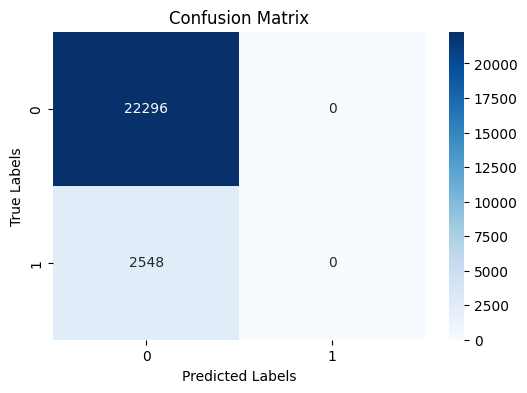

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load features
def load_features(file):
    data = np.load(file)
    return data['X'], data['y']

X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# Reshape dữ liệu để phù hợp với RNN
X_train = np.transpose(X_train, (0, 2, 1))  # (samples, timesteps, features)
X_dev = np.transpose(X_dev, (0, 2, 1))

# One-hot encoding nhãn
y_train = to_categorical(y_train)
y_dev = to_categorical(y_dev)

# Xây dựng mô hình RNN
model = Sequential([
    SimpleRNN(128, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    SimpleRNN(64, return_sequences=True),
    Dropout(0.3),
    SimpleRNN(32),
    Dropout(0.3),
    Dense(y_train.shape[1], activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Huấn luyện mô hình
model.fit(X_train, y_train, validation_data=(X_dev, y_dev), epochs=100, batch_size=32)

# Đánh giá trên tập kiểm tra
y_pred = model.predict(X_dev)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_dev, axis=1)

acc = accuracy_score(y_true, y_pred_classes)
auc = roc_auc_score(y_dev, y_pred, multi_class='ovr')
f1 = f1_score(y_true, y_pred_classes, average='weighted')
conf_matrix = confusion_matrix(y_true, y_pred_classes)
err = 1 - acc

print(f"Evaluation Accuracy: {acc:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Error Rate: {err:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

# Vẽ confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Lưu mô hình
model.save("rnn_speech_model.h5")


11. ***MÔ HÌNH TRANSFORMER***

Epoch 1/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 88s 107ms/step - accuracy: 0.8704 - loss: 0.7349 - val_accuracy: 0.9380 - val_loss: 0.1409
Epoch 2/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 83s 105ms/step - accuracy: 0.9634 - loss: 0.0980 - val_accuracy: 0.9499 - val_loss: 0.1499
Epoch 3/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 84s 106ms/step - accuracy: 0.9751 - loss: 0.0664 - val_accuracy: 0.9550 - val_loss: 0.1510
Epoch 4/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 85s 107ms/step - accuracy: 0.9798 - loss: 0.0566 - val_accuracy: 0.9579 - val_loss: 0.1281
Epoch 5/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 85s 107ms/step - accuracy: 0.9845 - loss: 0.0455 - val_accuracy: 0.9582 - val_loss: 0.1269
Epoch 6/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 86s 108ms/step - accuracy: 0.9827 - loss: 0.0490 - val_accuracy: 0.9279 - val_loss: 0.2167
Epoch 7/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 86s 108ms/step - accuracy: 0.9849 - loss: 0.0447 - val_accuracy: 0.9595 - val_loss: 0.1223
Epoch 8/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 85s 108ms/step - accuracy: 0.9836 -

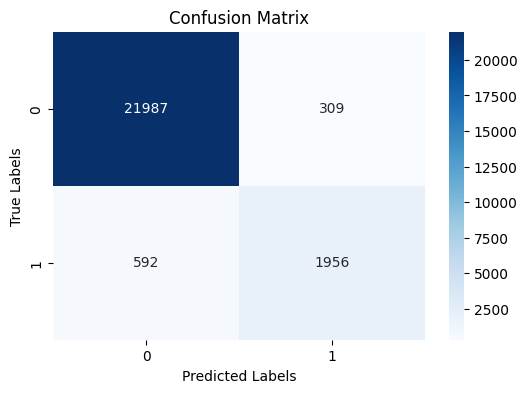

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization, MultiHeadAttention, Embedding, Input, GlobalAveragePooling1D
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix

# Load features
def load_features(file):
    data = np.load(file)
    return data['X'], data['y']

X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# Reshape dữ liệu để phù hợp với Transformer
X_train = np.transpose(X_train, (0, 2, 1))  # (samples, timesteps, features)
X_dev = np.transpose(X_dev, (0, 2, 1))

# One-hot encoding nhãn
y_train = to_categorical(y_train)
y_dev = to_categorical(y_dev)

# Xây dựng Transformer Encoder Layer
def transformer_encoder(inputs, head_size=64, num_heads=2, ff_dim=128, dropout=0.1):
    x = MultiHeadAttention(key_dim=head_size, num_heads=num_heads)(inputs, inputs)
    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    res = x + inputs
    
    x = Dense(ff_dim, activation="relu")(res)
    x = Dropout(dropout)(x)
    x = Dense(inputs.shape[-1])(x)
    x = LayerNormalization(epsilon=1e-6)(x)
    return x + res

# Định nghĩa mô hình Transformer
input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))
x = transformer_encoder(input_layer)
x = GlobalAveragePooling1D()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.3)(x)
out_layer = Dense(y_train.shape[1], activation="softmax")(x)

model = Model(inputs=input_layer, outputs=out_layer)
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Huấn luyện mô hình
model.fit(X_train, y_train, validation_data=(X_dev, y_dev), epochs=100, batch_size=32)

# Đánh giá trên tập kiểm tra
y_pred = model.predict(X_dev)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_dev, axis=1)

acc = accuracy_score(y_true, y_pred_classes)
auc = roc_auc_score(y_dev, y_pred, multi_class='ovr')
f1 = f1_score(y_true, y_pred_classes, average='weighted')
conf_matrix = confusion_matrix(y_true, y_pred_classes)
err = 1 - acc

print(f"Evaluation Accuracy: {acc:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Error Rate: {err:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

# Vẽ confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Lưu mô hình
model.save("transformer_speech_model.h5")

***12.MÔ HÌNH WAVENET***

Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 400, 13)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 400, 64)   │      1,728 │ input_layer_10[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_27 (Conv1D)  │ (None, 400, 64)   │      8,256 │ conv1d_26[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 64)   │        256 │ conv1d_27[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_29          │ (None, 400, 64)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_28 (Conv1D)  │ (None, 400, 64)   │      4,160 │ dropout_29[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_14 (Add)        │ (None, 400, 64)   │          0 │ conv1d_28[0][0],  │
│                     │                   │            │ conv1d_26[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_29 (Conv1D)  │ (None, 400, 64)   │      8,256 │ add_14[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 64)   │        256 │ conv1d_29[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_30          │ (None, 400, 64)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_30 (Conv1D)  │ (None, 400, 64)   │      4,160 │ dropout_30[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_15 (Add)        │ (None, 400, 64)   │          0 │ conv1d_30[0][0],  │
│                     │                   │            │ add_14[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_31 (Conv1D)  │ (None, 400, 64)   │      8,256 │ add_15[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 64)   │        256 │ conv1d_31[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_31          │ (None, 400, 64)   │          0 │ batch_normalizat… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_32 (Conv1D)  │ (None, 400, 64)   │      4,160 │ dropout_31[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_16 (Add)        │ (None, 400, 64)   │          0 │ conv1d_32[0][0],  │
│                     │                   │            │ add_15[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_33 (Conv1D)  │ (None, 400, 64)   │      8,256 │ add_16[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 400, 64)   │        256 │ conv1d_33[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 86,338 (337.26 KB)

 Trainable params: 85,570 (334.26 KB)

 Non-trainable params: 768 (3.00 KB)

Epoch 1/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 135s 161ms/step - accuracy: 0.9069 - loss: 0.3503 - val_accuracy: 0.9182 - val_loss: 0.4218
Epoch 2/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 88s 110ms/step - accuracy: 0.9820 - loss: 0.0502 - val_accuracy: 0.9531 - val_loss: 0.1604
Epoch 3/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 89s 112ms/step - accuracy: 0.9910 - loss: 0.0269 - val_accuracy: 0.9525 - val_loss: 0.1663
Epoch 4/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 125s 158ms/step - accuracy: 0.9938 - loss: 0.0202 - val_accuracy: 0.9750 - val_loss: 0.1054
Epoch 5/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 93s 117ms/step - accuracy: 0.9941 - loss: 0.0177 - val_accuracy: 0.9794 - val_loss: 0.0638
Epoch 6/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 92s 116ms/step - accuracy: 0.9942 - loss: 0.0151 - val_accuracy: 0.9791 - val_loss: 0.0742
Epoch 7/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 100s 126ms/step - accuracy: 0.9968 - loss: 0.0109 - val_accuracy: 0.9792 - val_loss: 0.0815
Epoch 8/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 165s 208ms/step - accuracy: 0.99

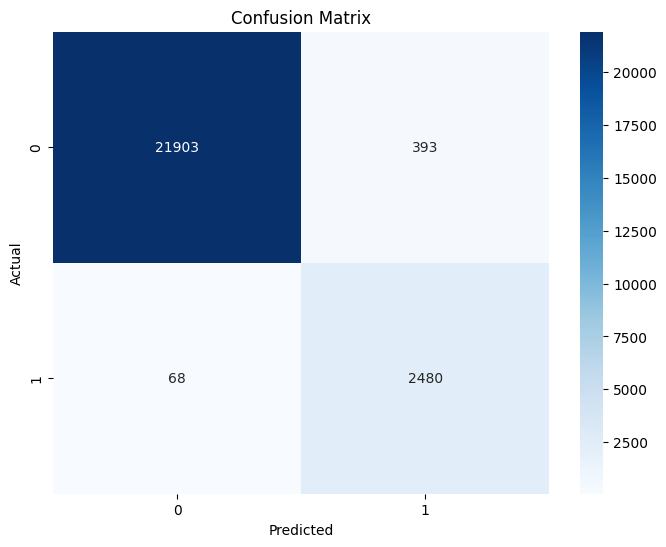

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, Dense, Dropout, Add, Activation, BatchNormalization
from tensorflow.keras.layers import GlobalAveragePooling1D
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix

# Load features
def load_features(file):
    data = np.load(file)
    return data['X'], data['y']

X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# Reshape dữ liệu để phù hợp với WaveNet: (n_samples, max_length, n_mfcc)
X_train = np.transpose(X_train, (0, 2, 1))  # (samples, timesteps, features)
X_dev = np.transpose(X_dev, (0, 2, 1))

# One-hot encoding nhãn
y_train = to_categorical(y_train)
y_dev = to_categorical(y_dev)

# WaveNet Block
def wavenet_block(x, dilation_rate):
    res_x = x
    x = Conv1D(64, kernel_size=2, padding="causal", dilation_rate=dilation_rate, activation="relu")(x)
    x = BatchNormalization()(x)
    x = Dropout(0.2)(x)
    x = Conv1D(64, kernel_size=1, activation="relu")(x)
    x = Add()([x, res_x])  # Skip Connection
    return x

# Xây dựng mô hình WaveNet
def build_wavenet(input_shape):
    inputs = Input(shape=input_shape)
    
    x = Conv1D(64, kernel_size=2, padding="causal", activation="relu")(inputs)
    
    for dilation_rate in [1, 2, 4, 8, 16, 32]:
        x = wavenet_block(x, dilation_rate)
    
    # Thêm Global Average Pooling để giảm chiều thời gian
    x = GlobalAveragePooling1D()(x)  
    
    x = Dense(128, activation="relu")(x)
    x = Dropout(0.3)(x)
    x = Dense(y_train.shape[1], activation="softmax")(x)
    
    model = Model(inputs, x)
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model


# Khởi tạo mô hình
input_shape = (X_train.shape[1], X_train.shape[2])  # (max_length, n_mfcc)
model = build_wavenet(input_shape)
model.summary()

# Huấn luyện mô hình
history = model.fit(X_train, y_train, validation_data=(X_dev, y_dev), epochs=100, batch_size=32)

# Đánh giá mô hình trên tập dev
y_pred = model.predict(X_dev)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_dev, axis=1)

acc = accuracy_score(y_true, y_pred_classes)
auc = roc_auc_score(y_dev, y_pred, multi_class='ovr')
f1 = f1_score(y_true, y_pred_classes, average='weighted')
conf_matrix = confusion_matrix(y_true, y_pred_classes)

print(f"Accuracy: {acc:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"F1 Score: {f1:.4f}")

# Vẽ confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_true), yticklabels=np.unique(y_true))
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# Lưu mô hình
model.save("wavenet_speech_model.h5")

***13. MÔ HÌNH XGBOOST***

[0]	validation_0-auc:0.94263
[1]	validation_0-auc:0.95413
[2]	validation_0-auc:0.95882
[3]	validation_0-auc:0.96033
[4]	validation_0-auc:0.96281
[5]	validation_0-auc:0.96539
[6]	validation_0-auc:0.96764
[7]	validation_0-auc:0.96939
[8]	validation_0-auc:0.97090
[9]	validation_0-auc:0.97108
[10]	validation_0-auc:0.97179
[11]	validation_0-auc:0.97213
[12]	validation_0-auc:0.97251
[13]	validation_0-auc:0.97250
[14]	validation_0-auc:0.97250
[15]	validation_0-auc:0.97293
[16]	validation_0-auc:0.97288
[17]	validation_0-auc:0.97285
[18]	validation_0-auc:0.97321
[19]	validation_0-auc:0.97338
[20]	validation_0-auc:0.97321
[21]	validation_0-auc:0.97341
[22]	validation_0-auc:0.97360
[23]	validation_0-auc:0.97358
[24]	validation_0-auc:0.97352
[25]	validation_0-auc:0.97335
[26]	validation_0-auc:0.97359
[27]	validation_0-auc:0.97361
[28]	validation_0-auc:0.97373
[29]	validation_0-auc:0.97421
[30]	validation_0-auc:0.97415
[31]	validation_0-auc:0.97422
[32]	validation_0-auc:0.97445
[33]	validation_0-au

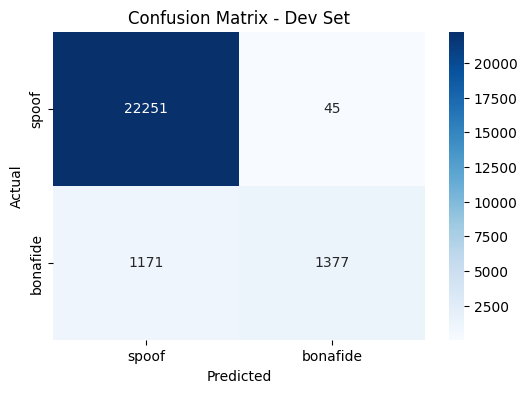

In [ ]:
import numpy as np
import xgboost as xgb
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load features
def load_features(file):
    data = np.load(file)
    return data['X'], data['y']

X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")
#X_eval, y_eval = load_features("eval_features.npz")

# Reshape dữ liệu thành dạng 2D để phù hợp với XGBoost
X_train = X_train.reshape(X_train.shape[0], -1)
X_dev = X_dev.reshape(X_dev.shape[0], -1)
#X_eval = X_eval.reshape(X_eval.shape[0], -1)

# Khởi tạo và huấn luyện mô hình XGBoost với thông số tối ưu
model = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="auc",
    n_estimators=500,
    max_depth=8,
    learning_rate=0.01,
    subsample=0.9,
    colsample_bytree=0.9,
    gamma=0.1,
    min_child_weight=1,
    reg_lambda=1.0,
    reg_alpha=0.1,
    random_state=42, early_stopping_rounds=30,
)

model.fit(X_train, y_train, eval_set=[(X_dev, y_dev)], verbose=True)

# Dự đoán và đánh giá trên tập dev
y_dev_pred = model.predict(X_dev)
y_dev_prob = model.predict_proba(X_dev)[:, 1]

acc = accuracy_score(y_dev, y_dev_pred)
auc = roc_auc_score(y_dev, y_dev_prob)
f1 = f1_score(y_dev, y_dev_pred)
cm = confusion_matrix(y_dev, y_dev_pred)

print("\n=== Evaluation on Development Set ===")
print(f"Accuracy: {acc:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Classification Report:\n", classification_report(y_dev, y_dev_pred))

# Vẽ confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["spoof", "bonafide"], yticklabels=["spoof", "bonafide"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Dev Set")
plt.show()

# Đánh giá trên tập kiểm tra
'''y_eval_pred = model.predict(X_eval)
y_eval_prob = model.predict_proba(X_eval)[:, 1]

acc_eval = accuracy_score(y_eval, y_eval_pred)
auc_eval = roc_auc_score(y_eval, y_eval_prob)
f1_eval = f1_score(y_eval, y_eval_pred)

print("\n=== Evaluation on Test Set ===")
print(f"Accuracy: {acc_eval:.4f}")
print(f"AUC Score: {auc_eval:.4f}")
print(f"F1 Score: {f1_eval:.4f}") '''

# Lưu mô hình
model.save_model("xgboost_speech_model.json")


***14. MÔ HÌNH RESNET***

Epoch 1/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 161s 197ms/step - accuracy: 0.9288 - loss: 0.1721 - val_accuracy: 0.9648 - val_loss: 0.1031
Epoch 2/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 175s 220ms/step - accuracy: 0.9864 - loss: 0.0422 - val_accuracy: 0.6202 - val_loss: 1.0572
Epoch 3/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 179s 225ms/step - accuracy: 0.9901 - loss: 0.0297 - val_accuracy: 0.9461 - val_loss: 0.2208
Epoch 4/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 177s 223ms/step - accuracy: 0.9933 - loss: 0.0216 - val_accuracy: 0.9675 - val_loss: 0.1119
Epoch 5/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 182s 230ms/step - accuracy: 0.9958 - loss: 0.0149 - val_accuracy: 0.9728 - val_loss: 0.1013
Epoch 6/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 184s 232ms/step - accuracy: 0.9936 - loss: 0.0181 - val_accuracy: 0.9785 - val_loss: 0.0612
Epoch 7/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 156s 196ms/step - accuracy: 0.9955 - loss: 0.0127 - val_accuracy: 0.9452 - val_loss: 0.1730
Epoch 8/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 126s 159ms/step - accuracy: 

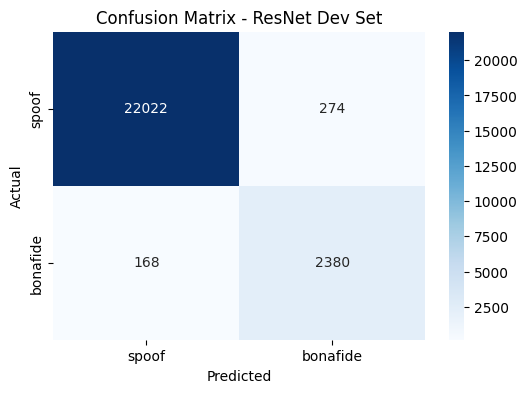

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, BatchNormalization, Activation, Add, GlobalAveragePooling1D, Dense
)
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load và chuẩn hóa dữ liệu
def load_features(file):
    data = np.load(file)
    return data['X'], data['y']

X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# Reshape lại thành (samples, timesteps, features) để phù hợp với Conv1D
X_train = np.transpose(X_train, (0, 2, 1))  # (N, 400, 13)
X_dev = np.transpose(X_dev, (0, 2, 1))

# Hàm tạo block ResNet
def resnet_block(inputs, filters, kernel_size=3, strides=1):
    x = Conv1D(filters, kernel_size, strides=strides, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = Conv1D(filters, kernel_size, strides=1, padding="same")(x)
    x = BatchNormalization()(x)

    if strides != 1 or inputs.shape[-1] != filters:
        shortcut = Conv1D(filters, 1, strides=strides, padding="same")(inputs)
        shortcut = BatchNormalization()(shortcut)
    else:
        shortcut = inputs

    x = Add()([x, shortcut])
    x = Activation("relu")(x)
    return x

# Xây dựng mô hình ResNet
def build_resnet(input_shape):
    inputs = Input(shape=input_shape)
    x = Conv1D(64, 3, strides=1, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)

    x = resnet_block(x, 64)
    x = resnet_block(x, 64)
    x = resnet_block(x, 128, strides=2)
    x = resnet_block(x, 128)

    x = GlobalAveragePooling1D()(x)
    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

model = build_resnet(X_train.shape[1:])

# Huấn luyện
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, y_train,
                    validation_data=(X_dev, y_dev),
                    epochs=100,
                    batch_size=32,
                    callbacks=[early_stop],
                    verbose=1)

# Đánh giá
y_dev_prob = model.predict(X_dev).flatten()
y_dev_pred = (y_dev_prob > 0.5).astype(int)

acc = accuracy_score(y_dev, y_dev_pred)
auc = roc_auc_score(y_dev, y_dev_prob)
f1 = f1_score(y_dev, y_dev_pred)
cm = confusion_matrix(y_dev, y_dev_pred)

print(f"Accuracy: {acc:.4f}")
print(f"AUC: {auc:.4f}")
print(f"F1-Score: {f1:.4f}")
print("Classification Report:\n", classification_report(y_dev, y_dev_pred))

# Vẽ confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["spoof", "bonafide"], yticklabels=["spoof", "bonafide"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - ResNet Dev Set")
plt.show()
# Lưu mô hình đã huấn luyện
model.save("resnet_speech_model.h5")

***15. MÔ HÌNH LOGISTIC REGRESSION***

C:\Users\VanKhanh\AppData\Roaming\Python\Python311\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



=== Evaluation on Development Set ===
Accuracy: 0.9417
AUC Score: 0.9497
F1 Score: 0.6791
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.98      0.97     22296
           1       0.78      0.60      0.68      2548

    accuracy                           0.94     24844
   macro avg       0.87      0.79      0.82     24844
weighted avg       0.94      0.94      0.94     24844



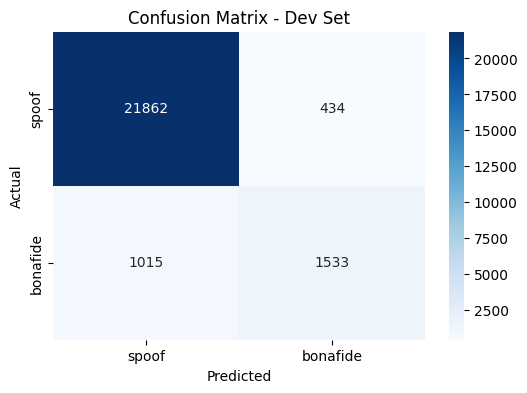

['logistic_regression_speech_model.pkl']

In [ ]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Load features
def load_features(file):
    data = np.load(file)
    return data['X'], data['y']

X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")
'''X_eval, y_eval = load_features("eval_features.npz")'''

# Reshape dữ liệu thành dạng 2D để phù hợp với Logistic Regression
X_train = X_train.reshape(X_train.shape[0], -1)
X_dev = X_dev.reshape(X_dev.shape[0], -1)
'''X_eval = X_eval.reshape(X_eval.shape[0], -1)'''

# Khởi tạo và huấn luyện mô hình Logistic Regression
model = LogisticRegression(max_iter=500, random_state=42)
model.fit(X_train, y_train)

# Dự đoán và đánh giá trên tập dev
y_dev_pred = model.predict(X_dev)
y_dev_prob = model.predict_proba(X_dev)[:, 1]

acc = accuracy_score(y_dev, y_dev_pred)
auc = roc_auc_score(y_dev, y_dev_prob)
f1 = f1_score(y_dev, y_dev_pred)
cm = confusion_matrix(y_dev, y_dev_pred)

print("\n=== Evaluation on Development Set ===")
print(f"Accuracy: {acc:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Classification Report:\n", classification_report(y_dev, y_dev_pred))

# Vẽ confusion matrix
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["spoof", "bonafide"], yticklabels=["spoof", "bonafide"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Dev Set")
plt.show()

# Đánh giá trên tập kiểm tra
'''y_eval_pred = model.predict(X_eval)
y_eval_prob = model.predict_proba(X_eval)[:, 1]

acc_eval = accuracy_score(y_eval, y_eval_pred)
auc_eval = roc_auc_score(y_eval, y_eval_prob)
f1_eval = f1_score(y_eval, y_eval_pred)

print("\n=== Evaluation on Test Set ===")
print(f"Accuracy: {acc_eval:.4f}")
print(f"AUC Score: {auc_eval:.4f}")
print(f"F1 Score: {f1_eval:.4f}")'''

# Lưu mô hình
import joblib
joblib.dump(model, "logistic_regression_speech_model.pkl")


***16. MÔ HÌNH DECISION TREE***

Loading features...
Accuracy: 0.9278296570600547
F1 Score (macro): 0.7686870734756113
AUC: 0.7293231878327219


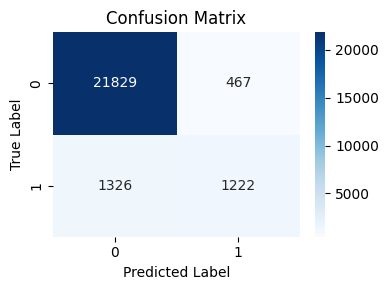

['decision_tree_model.joblib']

In [ ]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Hàm tải đặc trưng từ file .npz
def load_features(feature_file):
    data = np.load(feature_file)
    X = data['X'].reshape(data['X'].shape[0], -1)  # Làm phẳng đặc trưng
    y = data['y']
    return X, y

# Tải dữ liệu đã trích xuất
print("Loading features...")
X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# Chuẩn hóa (tùy chọn nhưng khuyến khích)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_dev = scaler.transform(X_dev)

# Huấn luyện mô hình Decision Tree
clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)

# Dự đoán trên tập phát triển
y_pred = clf.predict(X_dev)

# Tính toán các chỉ số
acc = accuracy_score(y_dev, y_pred)
f1 = f1_score(y_dev, y_pred, average='macro')
cm = confusion_matrix(y_dev, y_pred)
print("Accuracy:", acc)
print("F1 Score (macro):", f1)

# Kiểm tra nếu là bài toán nhị phân để tính AUC
if len(np.unique(y_dev)) == 2:
    y_proba = clf.predict_proba(X_dev)[:, 1]
    auc = roc_auc_score(y_dev, y_proba)
    print("AUC:", auc)
else:
    print("AUC: Không áp dụng được cho bài toán đa lớp theo cách này")

# In confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_dev), yticklabels=np.unique(y_dev))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

# (Tùy chọn) Lưu mô hình
joblib.dump(clf, "decision_tree_model.joblib")


***17. MÔ HÌNH GMM***

Evaluation Accuracy: 0.8882
AUC Score: 0.4952
F1 Score: 0.8444
Confusion Matrix:
[[22064   232]
 [ 2546     2]]


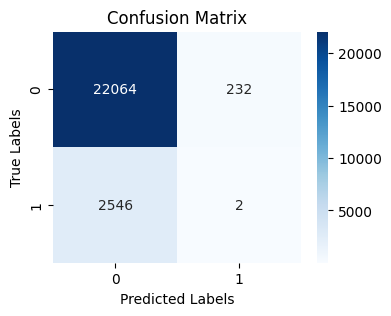

['gmm_speech_model.pkl']

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, roc_auc_score
from tensorflow.keras.utils import to_categorical

# Load features
def load_features(file):
    data = np.load(file)
    return data['X'], data['y']

X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# Reshape and normalize dữ liệu
def preprocess_features(X):
    # Đảm bảo dữ liệu có shape (samples, features)
    X = X.reshape(X.shape[0], -1)
    # Chuẩn hóa dữ liệu
    scaler = StandardScaler()
    X = scaler.fit_transform(X)
    return X

X_train = preprocess_features(X_train)
X_dev = preprocess_features(X_dev)

# Chuyển đổi nhãn thành One-hot encoding
y_train_one_hot = to_categorical(y_train)
y_dev_one_hot = to_categorical(y_dev)

# Huấn luyện mô hình GMM
n_components = len(np.unique(y_train))  # Số lượng component = số lớp (classes)
gmm = GaussianMixture(n_components=n_components, covariance_type='full', random_state=42)

# Fit GMM với dữ liệu huấn luyện
gmm.fit(X_train)

# Dự đoán trên tập phát triển (dev set)
y_pred_gmm = gmm.predict(X_dev)

# Tính xác suất cho AUC
y_dev_prob = gmm.predict_proba(X_dev)[:, 1]
auc = roc_auc_score(y_dev, y_dev_prob)

# Đánh giá mô hình
acc = accuracy_score(y_dev, y_pred_gmm)
f1 = f1_score(y_dev, y_pred_gmm, average='weighted')
conf_matrix = confusion_matrix(y_dev, y_pred_gmm)

# Tính AUC (ROC AUC)
#auc = roc_auc_score(y_dev_one_hot, y_pred_probs, multi_class='ovr')

print(f"Evaluation Accuracy: {acc:.4f}")
print(f"AUC Score: {auc:.4f}")
print(f"F1 Score: {f1:.4f}")
print("Confusion Matrix:")
print(conf_matrix)

# Vẽ confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=np.unique(y_dev), yticklabels=np.unique(y_dev))
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Lưu mô hình GMM
import joblib
joblib.dump(gmm, 'gmm_speech_model.pkl')


***18. MÔ HÌNH DNN***

Loading features...
Preprocessing data...


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ permute_3 (Permute)             │ (None, 400, 13, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_3 (Reshape)             │ (None, 400, 13)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_8 (Conv1D)               │ (None, 400, 64)        │         2,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 400, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_8 (MaxPooling1D)  │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_9 (Conv1D)               │ (None, 200, 128)       │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 200, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_9 (MaxPooling1D)  │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,339,649 (12.74 MB)

 Trainable params: 3,338,497 (12.74 MB)

...

794/794 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - accuracy: 0.9886 - auc: 0.9969 - loss: 0.0356 - precision: 0.9485 - recall: 0.9354 - val_accuracy: 0.9678 - val_auc: 0.9631 - val_loss: 0.1080 - val_precision: 0.9401 - val_recall: 0.7323 - learning_rate: 1.0000e-04
Epoch 9/100
793/794 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9915 - auc: 0.9976 - loss: 0.0287 - precision: 0.9617 - recall: 0.9512
Epoch 9: val_auc did not improve from 0.96311
794/794 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.9915 - auc: 0.9976 - loss: 0.0287 - precision: 0.9617 - recall: 0.9512 - val_accuracy: 0.9699 - val_auc: 0.9603 - val_loss: 0.1054 - val_precision: 0.9434 - val_recall: 0.7520 - learning_rate: 1.0000e-04
Epoch 10/100
793/794 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9921 - auc: 0.9973 - loss: 0.0252 - precision: 0.9645 - recall: 0.9574
Epoch 10: val_auc improved from 0.96311 to 0.96470, saving model to best_model.h5


794/794 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.9921 - auc: 0.9973 - loss: 0.0252 - precision: 0.9645 - recall: 0.9573 - val_accuracy: 0.9723 - val_auc: 0.9647 - val_loss: 0.0968 - val_precision: 0.9298 - val_recall: 0.7900 - learning_rate: 1.0000e-04
Epoch 11/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9935 - auc: 0.9977 - loss: 0.0239 - precision: 0.9760 - recall: 0.9628
Epoch 11: val_auc improved from 0.96470 to 0.96550, saving model to best_model.h5


794/794 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.9935 - auc: 0.9977 - loss: 0.0239 - precision: 0.9760 - recall: 0.9628 - val_accuracy: 0.9724 - val_auc: 0.9655 - val_loss: 0.0991 - val_precision: 0.9555 - val_recall: 0.7665 - learning_rate: 1.0000e-04
Epoch 12/100
793/794 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9944 - auc: 0.9990 - loss: 0.0189 - precision: 0.9787 - recall: 0.9659
Epoch 12: val_auc did not improve from 0.96550
794/794 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.9944 - auc: 0.9990 - loss: 0.0189 - precision: 0.9786 - recall: 0.9659 - val_accuracy: 0.9723 - val_auc: 0.9612 - val_loss: 0.1055 - val_precision: 0.9636 - val_recall: 0.7582 - learning_rate: 1.0000e-04
Epoch 13/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9943 - auc: 0.9991 - loss: 0.0171 - precision: 0.9780 - recall: 0.9663
Epoch 13: val_auc did not improve from 0.96550

Epoch 13: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
794/794 ━━━━━━━━━━━━━━━━━━

794/794 ━━━━━━━━━━━━━━━━━━━━ 34s 42ms/step - accuracy: 0.9972 - auc: 0.9998 - loss: 0.0091 - precision: 0.9893 - recall: 0.9831 - val_accuracy: 0.9790 - val_auc: 0.9704 - val_loss: 0.0802 - val_precision: 0.9638 - val_recall: 0.8261 - learning_rate: 2.5000e-05
Epoch 19/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9980 - auc: 0.9992 - loss: 0.0088 - precision: 0.9908 - recall: 0.9890
Epoch 19: val_auc did not improve from 0.97045
794/794 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.9980 - auc: 0.9992 - loss: 0.0088 - precision: 0.9908 - recall: 0.9889 - val_accuracy: 0.9763 - val_auc: 0.9638 - val_loss: 0.0963 - val_precision: 0.9813 - val_recall: 0.7834 - learning_rate: 2.5000e-05
Epoch 20/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.9963 - auc: 0.9995 - loss: 0.0108 - precision: 0.9838 - recall: 0.9787
Epoch 20: val_auc did not improve from 0.97045
794/794 ━━━━━━━━━━━━━━━━━━━━ 33s 42ms/step - accuracy: 0.9963 - auc: 0.9995 - loss: 0.0108 - precision: 

777/777 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step

Final Metrics on Dev Set:
Accuracy: 0.9790
AUC: 0.9815
F1-score: 0.8897

Detailed Classification Report:
              precision    recall  f1-score   support

    bonafide       0.98      1.00      0.99     22296
       spoof       0.96      0.83      0.89      2548

    accuracy                           0.98     24844
   macro avg       0.97      0.91      0.94     24844
weighted avg       0.98      0.98      0.98     24844



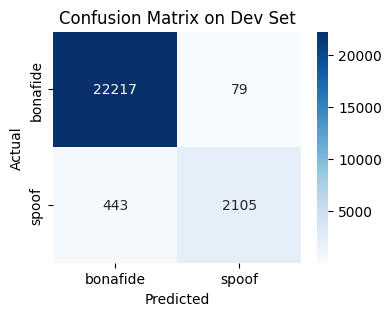

In [14]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score,f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Tải dữ liệu đặc trưng
def load_features(feature_file):
    data = np.load(feature_file)
    return data['X'], data['y']

print("Loading features...")
X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# 2. Tiền xử lý dữ liệu
print("Preprocessing data...")
# Chuẩn hóa theo mean và std của tập train
mean = np.mean(X_train, axis=(0, 2), keepdims=True)
std = np.std(X_train, axis=(0, 2), keepdims=True) + 1e-6
X_train = (X_train - mean) / std
X_dev = (X_dev - mean) / std

# Reshape dữ liệu (thêm chiều channel)
X_train = np.expand_dims(X_train, axis=-1)
X_dev = np.expand_dims(X_dev, axis=-1)

# 3. Xây dựng mô hình DNN cải tiến
def dnn(input_shape):
    model = models.Sequential([
        layers.Input(shape=input_shape),
        
        # Chuyển đổi chiều dữ liệu để phù hợp với Conv1D
        layers.Permute((2, 1, 3)),  # Chuyển từ (13, 400, 1) thành (400, 13, 1)
        layers.Reshape((400, 13)),   # Bỏ chiều cuối cùng (400, 13)
        
        # Lớp Conv1D
        layers.Conv1D(64, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Dropout(0.3),
        
        layers.Conv1D(128, 3, activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling1D(2),
        layers.Dropout(0.3),
        
        layers.Flatten(),
        
        # Lớp Dense
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),
        
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        
        # Lớp đầu ra
        layers.Dense(1, activation='sigmoid')
    ])
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
    
    model.compile(optimizer=optimizer,
                 loss='binary_crossentropy',
                 metrics=['accuracy',
                         tf.keras.metrics.Precision(name='precision'),
                         tf.keras.metrics.Recall(name='recall'),
                         tf.keras.metrics.AUC(name='auc')])
    
    return model

input_shape = X_train.shape[1:]
model = dnn(input_shape)
model.summary()

# 4. Callbacks để cải thiện quá trình huấn luyện
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', patience=10, restore_best_weights=True, verbose=1)

model_checkpoint = callbacks.ModelCheckpoint(
    'best_model.h5', monitor='val_auc', mode='max', save_best_only=True, verbose=1)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

# 5. Huấn luyện mô hình
print("Training model...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_dev, y_dev),
    epochs=100,
    batch_size=32,
    callbacks=[early_stopping, model_checkpoint, reduce_lr],
    verbose=1
)

# 6. Đánh giá mô hình trên tập dev
print("\nEvaluating on development set...")
best_model = models.load_model('best_model.h5')

# Dự đoán probabilities
y_pred_proba = best_model.predict(X_dev).flatten()
# Chuyển thành nhãn binary (0.5 là ngưỡng)
y_pred = (y_pred_proba > 0.5).astype(int)

# Tính các metrics
accuracy = np.mean(y_pred == y_dev)
auc = roc_auc_score(y_dev, y_pred_proba)
f1 = f1_score(y_dev, y_pred)

print(f"\nFinal Metrics on Dev Set:")
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(f"F1-score: {f1:.4f}")


# Classification report
print("\nDetailed Classification Report:")
print(classification_report(y_dev, y_pred, target_names=["bonafide", "spoof"]))

# Confusion matrix
cm = confusion_matrix(y_dev, y_pred)
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["bonafide", "spoof"],
            yticklabels=["bonafide", "spoof"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix on Dev Set')
plt.show()

***19. MÔ HÌNH SGD***

Loading training features...
Loading development features...
Training data shape after reshaping: (25380, 5200)
Development data shape after reshaping: (24844, 5200)
Scaler saved as mfcc_scaler.joblib
Training SGD classifier...
SGD model saved as audio_spoofing_sgd_model.joblib
Evaluating on development set...

--- Development Set Evaluation ---
Accuracy: 0.9428
AUC: 0.8821
F1-Score: 0.6704
Classification Report:
               precision    recall  f1-score   support

       spoof       0.95      0.99      0.97     22296
    bonafide       0.82      0.57      0.67      2548

    accuracy                           0.94     24844
   macro avg       0.89      0.78      0.82     24844
weighted avg       0.94      0.94      0.94     24844



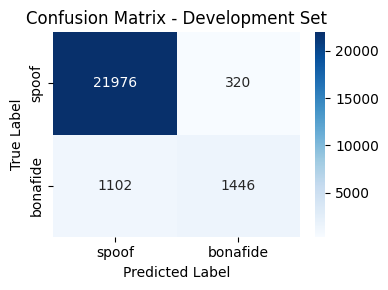

In [13]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Load pre-extracted features
print("Loading training features...")
train_data = np.load("train_features.npz")
X_train, y_train = train_data["X"], train_data["y"]

print("Loading development features...")
dev_data = np.load("dev_features.npz")
X_dev, y_dev = dev_data["X"], dev_data["y"]

# Reshape features for traditional ML model 
# Flattening the MFCC features to 2D array (samples, features)
X_train_reshaped = X_train.reshape(X_train.shape[0], -1)  # Reshape to (n_samples, n_mfcc * max_length)
X_dev_reshaped = X_dev.reshape(X_dev.shape[0], -1)

print(f"Training data shape after reshaping: {X_train_reshaped.shape}")
print(f"Development data shape after reshaping: {X_dev_reshaped.shape}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_reshaped)
X_dev_scaled = scaler.transform(X_dev_reshaped)

# Save the scaler for future use
joblib.dump(scaler, "mfcc_scaler.joblib")
print("Scaler saved as mfcc_scaler.joblib")

# Train SGD classifier
print("Training SGD classifier...")
sgd_clf = SGDClassifier(
    loss='log_loss',  # Logistic regression loss for probability estimates
    penalty='l2',     # L2 regularization to prevent overfitting
    alpha=0.0001,     # Regularization strength
    max_iter=1000,    # Maximum number of iterations
    tol=1e-3,         # Tolerance for stopping criterion
    random_state=42   # For reproducibility
)

sgd_clf.fit(X_train_scaled, y_train)

# Save the trained model
joblib.dump(sgd_clf, "SGDmodel.joblib")
print("SGD model saved as audio_spoofing_sgd_model.joblib")

# Function to evaluate and plot confusion matrix
def evaluate_model(y_true, y_pred, y_prob, dataset_name):
    acc = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    cm = confusion_matrix(y_true, y_pred)
    
    print(f"\n--- {dataset_name} Set Evaluation ---")
    print(f"Accuracy: {acc:.4f}")
    print(f"AUC: {auc:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("Classification Report:\n", classification_report(y_true, y_pred, target_names=["spoof", "bonafide"]))
    
    # Plot Confusion Matrix
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["spoof", "bonafide"], yticklabels=["spoof", "bonafide"])
    plt.title(f"Confusion Matrix - {dataset_name} Set")
    plt.ylabel("True Label")
    plt.xlabel("Predicted Label")
    plt.tight_layout()
    plt.savefig(f"{dataset_name}_confusion_matrix.png")
    plt.show()

# Evaluate on development set
print("Evaluating on development set...")
y_dev_prob = sgd_clf.predict_proba(X_dev_scaled)[:, 1]  # Get probabilities for positive class
y_dev_pred = sgd_clf.predict(X_dev_scaled)
evaluate_model(y_dev, y_dev_pred, y_dev_prob, "Development")



***20. MÔ HÌNH Linear Discriminant analysis***

Loading features...

Training LDA model...

Evaluation Results on Development Set
Accuracy: 0.9191
AUC: 0.9245
Macro F1-score: 0.7872

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.95     22296
           1       0.60      0.64      0.62      2548

    accuracy                           0.92     24844
   macro avg       0.78      0.80      0.79     24844
weighted avg       0.92      0.92      0.92     24844


Confusion Matrix:
[[21198  1098]
 [  911  1637]]


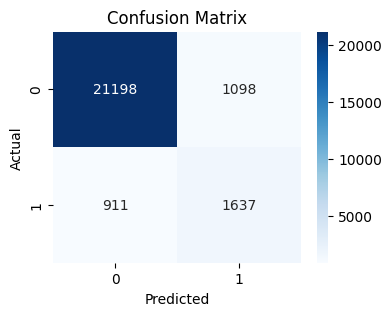


Trained LDA model saved to lda_model.pkl


In [15]:
import numpy as np
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                            confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. Load dữ liệu đặc trưng đã trích xuất
def load_features(file_path):
    data = np.load(file_path)
    return data['X'], data['y']

print("Loading features...")
X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# 2. Chuẩn bị dữ liệu cho LDA (reshape từ 3D sang 2D)
def reshape_features(X):
    return X.reshape(X.shape[0], -1)  # Flatten last two dimensions

X_train_flat = reshape_features(X_train)
X_dev_flat = reshape_features(X_dev)


# 3. Huấn luyện mô hình LDA
print("\nTraining LDA model...")
lda = LinearDiscriminantAnalysis()
lda.fit(X_train_flat, y_train)

# 4. Dự đoán trên tập dev
y_dev_pred = lda.predict(X_dev_flat)
y_dev_proba = lda.predict_proba(X_dev_flat)

# 5. Tính các metrics
accuracy = accuracy_score(y_dev, y_dev_pred)

# Tính AUC (cần xử lý multiclass nếu cần)
try:
    if len(lda.classes_) == 2:  # Binary classification
        auc = roc_auc_score(y_dev, y_dev_proba[:, 1])
    else:  # Multiclass classification
        auc = roc_auc_score(y_dev, y_dev_proba, multi_class='ovr')
except Exception as e:
    print(f"Could not calculate AUC: {e}")
    auc = None

# Tính F1-score (macro average)
f1 = f1_score(y_dev, y_dev_pred, average='macro')

# Confusion matrix
conf_mat = confusion_matrix(y_dev, y_dev_pred)

# 6. Hiển thị kết quả
print("\n" + "="*50)
print("Evaluation Results on Development Set")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
if auc is not None:
    print(f"AUC: {auc:.4f}")
print(f"Macro F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_dev, y_dev_pred))

print("\nConfusion Matrix:")
print(conf_mat)

# 7. Visualization
plt.figure(figsize=(4,3))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', 
            xticklabels=lda.classes_, yticklabels=lda.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 8. Lưu mô hình
model_filename = "lda_model.pkl"
joblib.dump(lda, model_filename)
print(f"\nTrained LDA model saved to {model_filename}")

***21. MÔ HÌNH Quadratic discrimimant analysis***

Loading features...

Preprocessing data...

Training QDA model...


c:\Users\VanKhanh\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
c:\Users\VanKhanh\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(



Evaluating model...

Evaluation Results
Accuracy: 0.8972
AUC: 0.4999
F1-Score (weighted): 0.8488

Classification Report:
              precision    recall  f1-score   support

           0       0.90      1.00      0.95     22296
           1       0.00      0.00      0.00      2548

    accuracy                           0.90     24844
   macro avg       0.45      0.50      0.47     24844
weighted avg       0.81      0.90      0.85     24844


Confusion Matrix:
[[22290     6]
 [ 2548     0]]


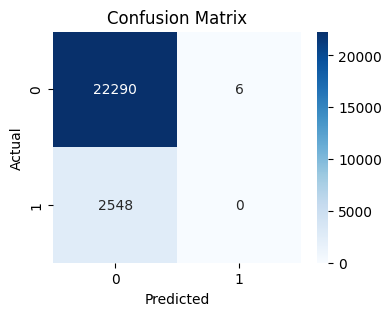


Saving artifacts...
Model and artifacts saved to 'qda_model_artifacts.joblib'


In [3]:
import numpy as np
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                            confusion_matrix, classification_report)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. Load dữ liệu đặc trưng
def load_features(file_path):
    data = np.load(file_path)
    return data['X'], data['y']

print("Loading features...")
X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# 2. Tiền xử lý dữ liệu
print("\nPreprocessing data...")
scaler = StandardScaler()
X_train_flat = X_train.reshape(X_train.shape[0], -1)  # Flatten thành (samples, features)
X_dev_flat = X_dev.reshape(X_dev.shape[0], -1)

X_train_scaled = scaler.fit_transform(X_train_flat)
X_dev_scaled = scaler.transform(X_dev_flat)

# 3. Huấn luyện QDA
print("\nTraining QDA model...")
try:
    qda = QuadraticDiscriminantAnalysis(store_covariance=True)
    qda.fit(X_train_scaled, y_train)
except Exception as e:
    print(f"Training failed: {str(e)}")
    raise

# 4. Đánh giá model
print("\nEvaluating model...")
y_pred = qda.predict(X_dev_scaled)
y_proba = qda.predict_proba(X_dev_scaled)

# Tính các metrics
accuracy = accuracy_score(y_dev, y_pred)
f1 = f1_score(y_dev, y_pred, average='weighted')

# Tính AUC (xử lý cả binary và multiclass)
if len(qda.classes_) == 2:
    auc = roc_auc_score(y_dev, y_proba[:, 1])
else:
    auc = roc_auc_score(y_dev, y_proba, multi_class='ovr')

# Confusion matrix
cm = confusion_matrix(y_dev, y_pred)

# 5. Hiển thị kết quả
print("\n" + "="*50)
print("Evaluation Results")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
print(f"AUC: {auc:.4f}")
print(f"F1-Score (weighted): {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_dev, y_pred))

print("\nConfusion Matrix:")
print(cm)

# Visualize confusion matrix
plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=qda.classes_, 
            yticklabels=qda.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('confusion_matrix.png')  # Lưu hình ảnh
plt.show()

# 6. Lưu model và các artifacts
print("\nSaving artifacts...")
artifacts = {
    'model': qda,
    'scaler': scaler,
    'classes': qda.classes_,
    'metrics': {
        'accuracy': accuracy,
        'auc': auc,
        'f1_score': f1,
        'confusion_matrix': cm
    }
}

joblib.dump(artifacts, 'qda_model_artifacts.joblib')
print("Model and artifacts saved to 'qda_model_artifacts.joblib'")

***22. MÔ HÌNH ADABOOST***

Loading features...

Kích thước dữ liệu:
Train: (25380, 5200), Nhãn: (25380,)
Dev: (24844, 5200), Nhãn: (24844,)

Training AdaBoost model...

Kết quả đánh giá trên tập Development (AdaBoost)
Accuracy: 0.9300
AUC: 0.9612
Macro F1-score: 0.7821

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.98      0.96     22296
           1       0.72      0.52      0.60      2548

    accuracy                           0.93     24844
   macro avg       0.83      0.75      0.78     24844
weighted avg       0.92      0.93      0.92     24844


Confusion Matrix:
[[21785   511]
 [ 1229  1319]]


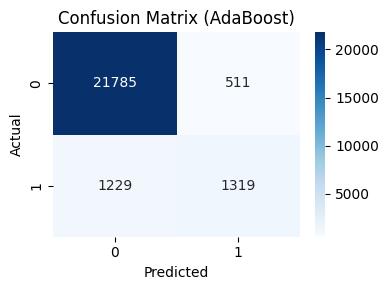


Đã lưu mô hình AdaBoost vào adaboost_model.pkl


In [9]:
import numpy as np
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                            confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. Load dữ liệu đặc trưng đã trích xuất
def load_features(file_path):
    try:
        data = np.load(file_path)
        return data['X'], data['y']
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None

print("Loading features...")
X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# Kiểm tra dữ liệu đã load
if X_train is None or X_dev is None:
    raise ValueError("Không thể load file đặc trưng")

# 2. Chuẩn bị dữ liệu (reshape từ 3D sang 2D)
def reshape_features(X):
    return X.reshape(X.shape[0], -1)  # Flatten các chiều MFCC và time steps

X_train_flat = reshape_features(X_train)
X_dev_flat = reshape_features(X_dev)

print("\nKích thước dữ liệu:")
print(f"Train: {X_train_flat.shape}, Nhãn: {y_train.shape}")
print(f"Dev: {X_dev_flat.shape}, Nhãn: {y_dev.shape}")

# 3. Huấn luyện mô hình AdaBoost
print("\nTraining AdaBoost model...")
try:
    # Sử dụng Decision Tree làm base estimator
    base_estimator = DecisionTreeClassifier(max_depth=1)  # Decision Stump
    
    # Tạo AdaBoost classifier
    ada = AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=1),  # Thay đổi ở đây
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    )
    
    ada.fit(X_train_flat, y_train)
except Exception as e:
    print(f"Lỗi khi huấn luyện AdaBoost: {e}")
    raise

# 4. Dự đoán trên tập dev
y_dev_pred = ada.predict(X_dev_flat)
y_dev_proba = ada.predict_proba(X_dev_flat)

# 5. Tính các metrics
accuracy = accuracy_score(y_dev, y_dev_pred)

# Tính AUC (xử lý cả binary và multiclass)
try:
    if len(ada.classes_) == 2:  # Binary classification
        auc = roc_auc_score(y_dev, y_dev_proba[:, 1])
    else:  # Multiclass classification
        auc = roc_auc_score(y_dev, y_dev_proba, multi_class='ovr')
except Exception as e:
    print(f"Không thể tính AUC: {e}")
    auc = None

# Tính F1-score (macro average)
f1 = f1_score(y_dev, y_dev_pred, average='macro')

# Confusion matrix
conf_mat = confusion_matrix(y_dev, y_dev_pred)

# 6. Hiển thị kết quả
print("\n" + "="*50)
print("Kết quả đánh giá trên tập Development (AdaBoost)")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
if auc is not None:
    print(f"AUC: {auc:.4f}")
print(f"Macro F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_dev, y_dev_pred))

print("\nConfusion Matrix:")
print(conf_mat)

# 7. Visualization
plt.figure(figsize=(4,3))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=ada.classes_, yticklabels=ada.classes_)
plt.title('Confusion Matrix (AdaBoost)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 8. Lưu mô hình
model_filename = "adaboost_model.pkl"
joblib.dump(ada, model_filename)
print(f"\nĐã lưu mô hình AdaBoost vào {model_filename}")

***23. MÔ HÌNH MLP CLASSIFIER***

Loading features...

Data shapes:
Train: (25380, 5200), Labels: (25380,)
Dev: (24844, 5200), Labels: (24844,)

Training MLP Classifier...
Iteration 1, loss = 0.08945887
Validation score: 0.984240
Iteration 2, loss = 0.03113904
Validation score: 0.985028
Iteration 3, loss = 0.01797039
Validation score: 0.988180
Iteration 4, loss = 0.01076450
Validation score: 0.988180
Iteration 5, loss = 0.01114299
Validation score: 0.989756
Iteration 6, loss = 0.01234057
Validation score: 0.985028
Iteration 7, loss = 0.01007486
Validation score: 0.990150
Iteration 8, loss = 0.00658903
Validation score: 0.988180
Iteration 9, loss = 0.00953401
Validation score: 0.992514
Iteration 10, loss = 0.00333221
Validation score: 0.990938
Iteration 11, loss = 0.00219499
Validation score: 0.993696
Iteration 12, loss = 0.00207378
Validation score: 0.993696
Iteration 13, loss = 0.00199000
Validation score: 0.993696
Iteration 14, loss = 0.00188879
Validation score: 0.993696
Iteration 15, loss = 0.00176390
Validation sc

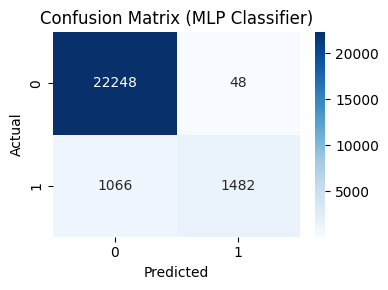


Trained MLP model saved to mlp_classifier_model.pkl
Scaler saved to mlp_scaler.pkl


In [13]:
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, f1_score, 
                            confusion_matrix, classification_report)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# 1. Load dữ liệu đặc trưng đã trích xuất
def load_features(file_path):
    try:
        data = np.load(file_path)
        return data['X'], data['y']
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return None, None

print("Loading features...")
X_train, y_train = load_features("train_features.npz")
X_dev, y_dev = load_features("dev_features.npz")

# Kiểm tra dữ liệu đã load
if X_train is None or X_dev is None:
    raise ValueError("Failed to load feature files")

# 2. Chuẩn bị dữ liệu (reshape từ 3D sang 2D và chuẩn hóa)
def prepare_data(X):
    # Flatten các chiều MFCC và time steps
    X_flat = X.reshape(X.shape[0], -1)
    # Chuẩn hóa dữ liệu
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_flat)
    return X_scaled, scaler

X_train_prepared, scaler = prepare_data(X_train)
X_dev_prepared = scaler.transform(X_dev.reshape(X_dev.shape[0], -1))

print("\nData shapes:")
print(f"Train: {X_train_prepared.shape}, Labels: {y_train.shape}")
print(f"Dev: {X_dev_prepared.shape}, Labels: {y_dev.shape}")

# 3. Huấn luyện mô hình MLP
print("\nTraining MLP Classifier...")
try:
    mlp = MLPClassifier(
        hidden_layer_sizes=(100, 50),  # 2 hidden layers (100 units và 50 units)
        activation='relu',            # Hàm kích hoạt
        solver='adam',                # Thuật toán tối ưu
        alpha=0.0001,                 # Tham số regularization
        batch_size=32,                # Kích thước batch
        learning_rate='adaptive',     # Tự động điều chỉnh learning rate
        max_iter=100,                 # Số epoch tối đa
        early_stopping=True,          # Dừng sớm nếu không cải thiện
        validation_fraction=0.1,      # Phần dữ liệu validation
        random_state=42,
        verbose=True                  # Hiển thị quá trình training
    )
    
    mlp.fit(X_train_prepared, y_train)
except Exception as e:
    print(f"Error training MLP: {e}")
    raise

# 4. Dự đoán trên tập dev
y_dev_pred = mlp.predict(X_dev_prepared)
y_dev_proba = mlp.predict_proba(X_dev_prepared)

# 5. Tính các metrics
accuracy = accuracy_score(y_dev, y_dev_pred)

# Tính AUC (xử lý cả binary và multiclass)
try:
    if len(mlp.classes_) == 2:  # Binary classification
        auc = roc_auc_score(y_dev, y_dev_proba[:, 1])
    else:  # Multiclass classification
        auc = roc_auc_score(y_dev, y_dev_proba, multi_class='ovr')
except Exception as e:
    print(f"Could not calculate AUC: {e}")
    auc = None

# Tính F1-score (macro average)
f1 = f1_score(y_dev, y_dev_pred, average='macro')

# Confusion matrix
conf_mat = confusion_matrix(y_dev, y_dev_pred)

# 6. Hiển thị kết quả
print("\n" + "="*50)
print("Evaluation Results on Development Set (MLP Classifier)")
print("="*50)
print(f"Accuracy: {accuracy:.4f}")
if auc is not None:
    print(f"AUC: {auc:.4f}")
print(f"Macro F1-score: {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_dev, y_dev_pred))

print("\nConfusion Matrix:")
print(conf_mat)

# 7. Visualization
plt.figure(figsize=(4,3))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=mlp.classes_, yticklabels=mlp.classes_)
plt.title('Confusion Matrix (MLP Classifier)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# 8. Lưu mô hình và scaler
model_filename = "mlp_classifier_model.pkl"
joblib.dump(mlp, model_filename)
print(f"\nTrained MLP model saved to {model_filename}")

scaler_filename = "mlp_scaler.pkl"
joblib.dump(scaler, scaler_filename)
print(f"Scaler saved to {scaler_filename}")

***24. MÔ HÌNH MFCMNet***

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (Input, Conv2D, MaxPooling2D, concatenate, 
                                    Flatten, Dense, Dropout, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import uuid
import joblib

# 1. Load and prepare data
def load_and_prepare_data():
    X_train = np.load("train_features.npz")['X']
    y_train = np.load("train_features.npz")['y']
    X_dev = np.load("dev_features.npz")['X']
    y_dev = np.load("dev_features.npz")['y']
    
    X_train = X_train[..., np.newaxis]
    X_dev = X_dev[..., np.newaxis]
    
    if len(np.unique(y_train)) > 2:
        y_train = tf.keras.utils.to_categorical(y_train)
        y_dev = tf.keras.utils.to_categorical(y_dev)
    
    return X_train, y_train, X_dev, y_dev

# 2. Build improved MFCMNet
def build_mfcmnet(input_shape, num_classes):
    inputs = Input(shape=input_shape)
    
    # Branch 1 - Small kernel
    branch1 = Conv2D(32, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01))(inputs)
    branch1 = BatchNormalization()(branch1)
    branch1 = MaxPooling2D((2, 2))(branch1)
    
    # Branch 2 - Medium kernel
    branch2 = Conv2D(32, (5, 5), activation='relu', padding='same', kernel_regularizer=l2(0.01))(inputs)
    branch2 = BatchNormalization()(branch2)
    branch2 = MaxPooling2D((2, 2))(branch2)
    
    # Branch 3 - Large kernel
    branch3 = Conv2D(32, (7, 7), activation='relu', padding='same', kernel_regularizer=l2(0.01))(inputs)
    branch3 = BatchNormalization()(branch3)
    branch3 = MaxPooling2D((2, 2))(branch3)
    
    merged = concatenate([branch1, branch2, branch3])
    
    x = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01))(merged)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.3)(x)
    
    x = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_regularizer=l2(0.01))(x)
    x = BatchNormalization()(x)
    x = MaxPooling2D((2, 2))(x)
    x = Dropout(0.3)(x)
    
    x = Flatten()(x)
    x = Dense(128, activation='relu', kernel_regularizer=l2(0.01))(x)
    x = Dropout(0.5)(x)
    
    if num_classes == 2:
        outputs = Dense(1, activation='sigmoid')(x)
    else:
        outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

# 3. Plot training history
def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('training_history.png')
    plt.close()

# 4. Evaluate model
def evaluate_model(model, X_dev, y_dev, num_classes):
    y_pred = model.predict(X_dev)
    y_pred_classes = np.argmax(y_pred, axis=1) if num_classes > 2 else (y_pred > 0.5).astype(int)
    y_true_classes = np.argmax(y_dev, axis=1) if num_classes > 2 else y_dev
    
    print("\nClassification Report:")
    print(classification_report(y_true_classes, y_pred_classes))
    
    f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')
    print(f"F1-Score (Weighted): {f1:.4f}")
    
    if num_classes == 2:
        auc = roc_auc_score(y_true_classes, y_pred)
        print(f"AUC: {auc:.4f}")
    else:
        auc = roc_auc_score(y_true_classes, y_pred, multi_class='ovr')
        print(f"AUC (One-vs-Rest): {auc:.4f}")
    
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=np.unique(y_true_classes), 
                yticklabels=np.unique(y_true_classes))
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('confusion_matrix.png')
    plt.close()

# 5. Main execution
def main():
    X_train, y_train, X_dev, y_dev = load_and_prepare_data()
    
    input_shape = X_train.shape[1:]
    num_classes = len(np.unique(y_train)) if len(y_train.shape) == 1 else y_train.shape[1]
    
    model = build_mfcmnet(input_shape, num_classes)
    
    model.compile(optimizer=Adam(learning_rate=0.001),
                  loss='binary_crossentropy' if num_classes == 2 else 'categorical_crossentropy',
                  metrics=['accuracy'])
    
    model.summary()
    
    # Data augmentation
    datagen = ImageDataGenerator(
        rotation_range=10,
        width_shift_range=0.1,
        height_shift_range=0.1,
        zoom_range=0.1,
        horizontal_flip=True
    )
    datagen.fit(X_train)
    
    # Callbacks
    callbacks = [
        EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
        ModelCheckpoint('best_mfcmnet_improved.h5', save_best_only=True, monitor='val_loss'),
        ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6)
    ]
    
    # Train model
    history = model.fit(
        datagen.flow(X_train, y_train, batch_size=32),
        validation_data=(X_dev, y_dev),
        epochs=100,
        callbacks=callbacks,
        verbose=1
    )
    
    # Load best model
    model.load_weights('best_mfcmnet_improved.h5')
    
    # Evaluate model
    evaluate_model(model, X_dev, y_dev, num_classes)
    
    # Plot training history
    plot_training_history(history)
    
    # Save model
    model.save('mfcmnet_improved_model.h5')
    print("Improved model saved as mfcmnet_improved_model.h5")


In [2]:

if __name__ == "__main__":
    main()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 13, 400,   │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 13, 400,   │        320 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 13, 400,   │        832 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 13, 400,   │      1,600 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 13, 400,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 400,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 13, 400,   │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 6, 200,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 6, 200,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 6, 200,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 6, 200,    │          0 │ max_pooling2d[0]… │
│ (Concatenate)       │ 96)               │            │ max_pooling2d_1[… │
│                     │                   │            │ max_pooling2d_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 6, 200,    │     55,360 │ concatenate[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 6, 200,    │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 3, 100,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 3, 100,    │          0 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 3, 100,    │     73,856 │ dropout[0][0]     │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 952,577 (3.63 MB)

 Trainable params: 952,001 (3.63 MB)

 Non-trainable params: 576 (2.25 KB)

...

794/794 ━━━━━━━━━━━━━━━━━━━━ 376s 474ms/step - accuracy: 0.9035 - loss: 0.2754 - val_accuracy: 0.9256 - val_loss: 0.1680 - learning_rate: 8.0000e-06
Epoch 52/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 392ms/step - accuracy: 0.8999 - loss: 0.2821

794/794 ━━━━━━━━━━━━━━━━━━━━ 368s 463ms/step - accuracy: 0.8999 - loss: 0.2821 - val_accuracy: 0.9298 - val_loss: 0.1659 - learning_rate: 8.0000e-06
Epoch 53/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 396ms/step - accuracy: 0.9037 - loss: 0.2733

794/794 ━━━━━━━━━━━━━━━━━━━━ 372s 468ms/step - accuracy: 0.9037 - loss: 0.2733 - val_accuracy: 0.9307 - val_loss: 0.1655 - learning_rate: 8.0000e-06
Epoch 54/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 265s 333ms/step - accuracy: 0.9046 - loss: 0.2675 - val_accuracy: 0.9222 - val_loss: 0.1726 - learning_rate: 8.0000e-06
Epoch 55/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 301s 379ms/step - accuracy: 0.9029 - loss: 0.2737 - val_accuracy: 0.9182 - val_loss: 0.1786 - learning_rate: 8.0000e-06
Epoch 56/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 1377s 2s/step - accuracy: 0.9013 - loss: 0.2780 - val_accuracy: 0.9185 - val_loss: 0.1872 - learning_rate: 8.0000e-06
Epoch 57/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 0s 546ms/step - accuracy: 0.9019 - loss: 0.2729

794/794 ━━━━━━━━━━━━━━━━━━━━ 462s 582ms/step - accuracy: 0.9019 - loss: 0.2729 - val_accuracy: 0.9360 - val_loss: 0.1568 - learning_rate: 8.0000e-06
Epoch 58/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 2224s 3s/step - accuracy: 0.9009 - loss: 0.2719 - val_accuracy: 0.9294 - val_loss: 0.1633 - learning_rate: 8.0000e-06
Epoch 59/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 209s 263ms/step - accuracy: 0.9017 - loss: 0.2745 - val_accuracy: 0.9291 - val_loss: 0.1650 - learning_rate: 8.0000e-06
Epoch 60/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 212s 267ms/step - accuracy: 0.9027 - loss: 0.2707 - val_accuracy: 0.9328 - val_loss: 0.1619 - learning_rate: 8.0000e-06
Epoch 61/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 213s 268ms/step - accuracy: 0.9041 - loss: 0.2700 - val_accuracy: 0.9280 - val_loss: 0.1714 - learning_rate: 8.0000e-06
Epoch 62/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 215s 271ms/step - accuracy: 0.9038 - loss: 0.2735 - val_accuracy: 0.9346 - val_loss: 0.1794 - learning_rate: 8.0000e-06
Epoch 63/100
794/794 ━━━━━━━━━━━━━━━━━━━━ 2

Improved model saved as mfcmnet_improved_model.h5


Model loaded successfully from mfcmnet_improved_model.h5
777/777 ━━━━━━━━━━━━━━━━━━━━ 59s 75ms/step

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     22296
           1       0.82      0.48      0.61      2548

    accuracy                           0.94     24844
   macro avg       0.88      0.74      0.79     24844
weighted avg       0.93      0.94      0.93     24844

F1-Score (Weighted): 0.9285
AUC: 0.9688


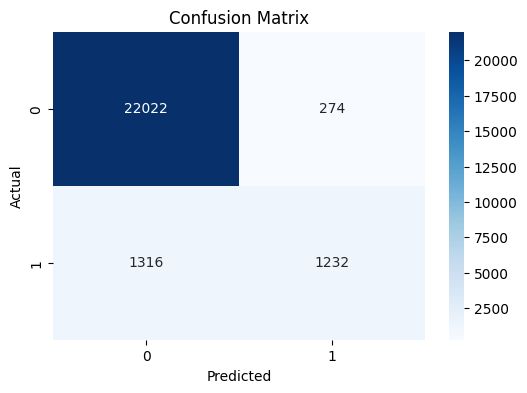

Confusion matrix saved as confusion_matrix.png


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Hàm tải và chuẩn bị dữ liệu (từ mã gốc)
def load_and_prepare_data():
    X_train = np.load("train_features.npz")['X']
    y_train = np.load("train_features.npz")['y']
    X_dev = np.load("dev_features.npz")['X']
    y_dev = np.load("dev_features.npz")['y']
    
    X_train = X_train[..., np.newaxis]
    X_dev = X_dev[..., np.newaxis]
    
    if len(np.unique(y_train)) > 2:
        y_train = tf.keras.utils.to_categorical(y_train)
        y_dev = tf.keras.utils.to_categorical(y_dev)
    
    return X_train, y_train, X_dev, y_dev

# Hàm đánh giá mô hình và in ma trận nhầm lẫn (từ mã gốc)
def evaluate_model(model, X_dev, y_dev, num_classes):
    y_pred = model.predict(X_dev)
    y_pred_classes = np.argmax(y_pred, axis=1) if num_classes > 2 else (y_pred > 0.5).astype(int)
    y_true_classes = np.argmax(y_dev, axis=1) if num_classes > 2 else y_dev
    
    print("\nClassification Report:")
    print(classification_report(y_true_classes, y_pred_classes))
    
    f1 = f1_score(y_true_classes, y_pred_classes, average='weighted')
    print(f"F1-Score (Weighted): {f1:.4f}")
    
    if num_classes == 2:
        auc = roc_auc_score(y_true_classes, y_pred)
        print(f"AUC: {auc:.4f}")
    else:
        auc = roc_auc_score(y_true_classes, y_pred, multi_class='ovr')
        print(f"AUC (One-vs-Rest): {auc:.4f}")
    
    cm = confusion_matrix(y_true_classes, y_pred_classes)
    plt.figure(figsize=(6,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=np.unique(y_true_classes), 
                yticklabels=np.unique(y_true_classes))
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.savefig('confusion_matrix.png')
    plt.show()  # Hiển thị ma trận nhầm lẫn
    plt.close()

# Hàm chính để tải mô hình và in ma trận nhầm lẫn
def main():
    # Tải dữ liệu
    _, _, X_dev, y_dev = load_and_prepare_data()
    
    # Tải mô hình đã lưu
    model = load_model('mfcmnet_improved_model.h5')
    print("Model loaded successfully from mfcmnet_improved_model.h5")
    
    # Xác định số lớp
    num_classes = len(np.unique(y_dev)) if len(y_dev.shape) == 1 else y_dev.shape[1]
    
    # Đánh giá mô hình và in ma trận nhầm lẫn
    evaluate_model(model, X_dev, y_dev, num_classes)
    print("Confusion matrix saved as confusion_matrix.png")

if __name__ == "__main__":
    main()